In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    cohen_kappa_score,
    f1_score
)

# ── Reproducibility ────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── Global Config ──────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── IMPORTANT: Update this path to your 3-class dataset ────────
# Your folder structure should be:
# BASE_DIR/train/jsn/
# BASE_DIR/train/normal/
# BASE_DIR/train/osteophyte/
# BASE_DIR/val/jsn/   etc.
# BASE_DIR/test/jsn/  etc.
BASE_DIR    = r"C:\Users\ASUS\Documents\4th year new\Splitted Dataset"

IMG_SIZE    = 32
EPOCHS      = 50
BATCH_SIZE  = 64

# ── 3 classes only — sclerosis removed ─────────────────────────
CLASS_NAMES = ["jsn", "normal", "osteophyte"]
NUM_CLASSES = 3

# ── Result folders ─────────────────────────────────────────────
for exp in ["exp1", "exp2", "exp3", "exp5", "final"]:
    os.makedirs(f"results_3class/{exp}", exist_ok=True)

# ── Global result stores ───────────────────────────────────────
ALL_RESULTS   = {}
ALL_HISTORIES = {}

print(f"Device      : {DEVICE}")
print(f"Classes     : {CLASS_NAMES}")
print(f"Num classes : {NUM_CLASSES}")
print(f"Sclerosis   : REMOVED (not needed for early stage KL0/1/2)")

Device      : cpu
Classes     : ['jsn', 'normal', 'osteophyte']
Num classes : 3
Sclerosis   : REMOVED (not needed for early stage KL0/1/2)


In [3]:
# ── Transforms ────────────────────────────────────────────────
transform_baseline = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

transform_augmented = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# ── Loaders ───────────────────────────────────────────────────
def get_loaders(train_transform=transform_baseline,
                batch_size=BATCH_SIZE):
    train_ds = datasets.ImageFolder(
        os.path.join(BASE_DIR, "train"),
        transform=train_transform)
    val_ds   = datasets.ImageFolder(
        os.path.join(BASE_DIR, "val"),
        transform=transform_baseline)
    test_ds  = datasets.ImageFolder(
        os.path.join(BASE_DIR, "test"),
        transform=transform_baseline)

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=0,
                              pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=0,
                              pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size,
                              shuffle=False, num_workers=0,
                              pin_memory=True)

    return train_loader, val_loader, test_loader, \
           train_ds.class_to_idx


def compute_class_weights(split="train"):
    path = os.path.join(BASE_DIR, split)
    ds   = datasets.ImageFolder(path,
                                 transform=transform_baseline)
    labels  = [label for _, label in ds.samples]
    counts  = Counter(labels)
    total   = sum(counts.values())
    n_cls   = len(counts)
    weights = [total / (n_cls * counts[c])
               for c in range(n_cls)]
    return torch.tensor(weights, dtype=torch.float).to(DEVICE)


# ── Verify dataset ─────────────────────────────────────────────
train_loader, val_loader, test_loader, class_map = get_loaders()
weights = compute_class_weights()

print(f"Class mapping : {class_map}")
print(f"Class weights : {weights}")
print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

# Count per class
for split in ["train", "val", "test"]:
    ds     = datasets.ImageFolder(
        os.path.join(BASE_DIR, split),
        transform=transform_baseline)
    counts = Counter([ds.classes[l] for _, l in ds.samples])
    print(f"\n{split.upper()} distribution:")
    for cls, cnt in sorted(counts.items()):
        print(f"  {cls:>12s}: {cnt}")

Class mapping : {'jsn': 0, 'normal': 1, 'osteophyte': 2}
Class weights : tensor([3.2280, 0.4142, 3.6221])
Train batches : 59
Val   batches : 13
Test  batches : 13

TRAIN distribution:
           jsn: 386
        normal: 3008
    osteophyte: 344

VAL distribution:
           jsn: 82
        normal: 644
    osteophyte: 73

TEST distribution:
           jsn: 84
        normal: 646
    osteophyte: 75


In [4]:
# ══════════════════════════════════════════════════════════════
#  ALL MODEL DEFINITIONS — 3 CLASS VERSION
#  Only change from 4-class: num_classes=3 throughout
# ══════════════════════════════════════════════════════════════

class BaselineCNN(nn.Module):
    """
    Experiment 1 — Baseline CNN
    3 conv blocks | dropout=0.4 | 3 output classes
    Classes: JSN | Normal | Osteophyte
    Sclerosis removed — not relevant for early KL0/1/2
    """
    def __init__(self, num_classes=3, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                    # 16×16

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2)                     # 8×8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

    def count_params(self):
        return sum(p.numel() for p in self.parameters()
                   if p.requires_grad)


class ShallowCNN(nn.Module):
    """
    Experiment 3A — Shallow CNN
    2 conv blocks | dropout=0.4 | 3 output classes
    Tests if baseline depth is over-engineered for 32×32
    """
    def __init__(self, num_classes=3, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                    # 16×16

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2)                     # 8×8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

    def count_params(self):
        return sum(p.numel() for p in self.parameters()
                   if p.requires_grad)


class DeepCNN(nn.Module):
    """
    Experiment 3C — Deep CNN
    4 conv blocks | dropout=0.4 | 3 output classes
    Tests whether extra depth captures subtle KL1 features
    Expected: overfits on 32×32 patches
    """
    def __init__(self, num_classes=3, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                    # 16×16

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),

            nn.Conv2d(128, 256, 3, padding=1),  # extra block
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2)                     # 8×8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

    def count_params(self):
        return sum(p.numel() for p in self.parameters()
                   if p.requires_grad)


# ── Model parameter summary ────────────────────────────────────
print("Model parameter counts (3-class):")
print(f"  ShallowCNN  : {ShallowCNN().count_params():,}")
print(f"  BaselineCNN : {BaselineCNN().count_params():,}")
print(f"  DeepCNN     : {DeepCNN().count_params():,}")

Model parameter counts (3-class):
  ShallowCNN  : 543,811
  BaselineCNN : 2,191,299
  DeepCNN     : 8,779,459


In [5]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter   = 0

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

    def reset(self):
        self.best_loss = float("inf")
        self.counter   = 0


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.size(0)

    return total_loss / len(loader), correct / total


def evaluate_loader(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y   = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss   = criterion(logits, y)

            total_loss += loss.item()
            correct    += (logits.argmax(1) == y).sum().item()
            total      += y.size(0)

    return total_loss / len(loader), correct / total


def run_training(model, train_loader, val_loader,
                 criterion, optimizer, save_path,
                 exp_name, epochs=EPOCHS):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    stopper      = EarlyStopping(patience=7)
    best_val_acc = 0.0
    history      = {
        "train_loss": [], "val_loss": [],
        "train_acc":  [], "val_acc":  []
    }

    print(f"\n{'='*65}")
    print(f"  {exp_name}")
    print(f"{'='*65}")
    print(f"  {'Epoch':>6} | {'TrLoss':>8} | {'TrAcc':>7} | "
          f"{'VlLoss':>8} | {'VlAcc':>7}")
    print(f"  {'-'*55}")

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = evaluate_loader(
            model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        print(f"  {epoch+1:>6} | {tr_loss:>8.4f} | "
              f"{tr_acc:>7.4f} | {vl_loss:>8.4f} | "
              f"{vl_acc:>7.4f}")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), save_path)

        if stopper.step(vl_loss):
            print(f"\n  Early stopping at epoch {epoch+1}")
            break

    print(f"\n  Best Val Acc : {best_val_acc:.4f}")
    return history


print("Training utilities loaded.")

Training utilities loaded.


In [6]:
ALL_RESULTS   = {}
ALL_HISTORIES = {}


def plot_learning_curves(history, exp_name, save_dir):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Learning Curves — {exp_name}",
                 fontsize=13, fontweight="bold")

    axes[0].plot(epochs, history["train_loss"],
                 label="Train", color="steelblue", linewidth=2)
    axes[0].plot(epochs, history["val_loss"],
                 label="Val",   color="tomato",    linewidth=2)
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history["train_acc"],
                 label="Train", color="steelblue", linewidth=2)
    axes[1].plot(epochs, history["val_acc"],
                 label="Val",   color="tomato",    linewidth=2)
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Gap annotation
    final_gap = (history["train_acc"][-1] -
                 history["val_acc"][-1])
    axes[1].annotate(
        f"Gap: {final_gap:.3f}",
        xy=(len(epochs), history["val_acc"][-1]),
        xytext=(len(epochs)*0.6, 0.5),
        arrowprops=dict(arrowstyle="->", color="gray"),
        fontsize=9, color="gray")

    plt.tight_layout()
    path = os.path.join(save_dir, f"{exp_name}_curves.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path}")


def plot_confusion_matrix(cm, class_names, exp_name, save_dir):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Confusion Matrix — {exp_name}",
                 fontsize=13, fontweight="bold")

    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ["d", ".2f"],
        ["Raw Counts", "Normalized"]
    ):
        sns.heatmap(data, annot=False, cmap="Blues",
                    xticklabels=class_names,
                    yticklabels=class_names, ax=ax,
                    linewidths=0.5)
        ax.set_title(title)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

        # Manual annotation with adaptive text color
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                val = data[i, j]
                threshold = data.max() * 0.5
                color = "white" if val > threshold else "black"
                text  = (f"{int(val)}" if fmt == "d"
                         else f"{val:.2f}")
                ax.text(j + 0.5, i + 0.5, text,
                        ha="center", va="center",
                        fontsize=11, fontweight="bold",
                        color=color)

    plt.tight_layout()
    path = os.path.join(save_dir, f"{exp_name}_cm.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path}")


def full_evaluate(model, test_loader, exp_name, save_dir,
                  class_names=CLASS_NAMES):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for x, y in test_loader:
            x      = x.to(DEVICE)
            logits = model(x)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            preds  = logits.argmax(dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    report   = classification_report(
        all_labels, all_preds,
        target_names=class_names, output_dict=True)
    kappa    = cohen_kappa_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    cm       = confusion_matrix(all_labels, all_preds)

    try:
        auc = roc_auc_score(
            all_labels, all_probs,
            multi_class="ovr", average=None)
    except ValueError:
        auc = np.zeros(len(class_names))

    # ── Print ──────────────────────────────────────────────────
    print(f"\n{'─'*55}")
    print(f"  RESULTS: {exp_name}")
    print(f"{'─'*55}")
    print(classification_report(
        all_labels, all_preds, target_names=class_names))
    print(f"  Cohen Kappa : {kappa:.4f}")
    print(f"  Macro F1    : {macro_f1:.4f}")
    for i, cls in enumerate(class_names):
        print(f"  AUC [{cls:>12s}]: {auc[i]:.4f}")

    # ── Save ───────────────────────────────────────────────────
    os.makedirs(save_dir, exist_ok=True)
    txt_path = os.path.join(save_dir, f"{exp_name}_metrics.txt")
    with open(txt_path, "w") as f:
        f.write(f"RESULTS: {exp_name}\n{'='*50}\n")
        f.write(classification_report(
            all_labels, all_preds, target_names=class_names))
        f.write(f"\nCohen Kappa : {kappa:.4f}\n")
        f.write(f"Macro F1    : {macro_f1:.4f}\n")
        for i, cls in enumerate(class_names):
            f.write(f"AUC [{cls}]: {auc[i]:.4f}\n")

    plot_confusion_matrix(cm, class_names, exp_name, save_dir)

    results = {
        "report":   report,
        "kappa":    kappa,
        "macro_f1": macro_f1,
        "auc":      auc,
        "cm":       cm
    }
    ALL_RESULTS[exp_name] = results
    return results


def plot_comparison(metric="macro_f1",
                    save_dir="results_3class/final"):
    if not ALL_RESULTS:
        print("No results yet.")
        return
    os.makedirs(save_dir, exist_ok=True)
    names  = list(ALL_RESULTS.keys())
    values = [ALL_RESULTS[n][metric] for n in names]
    colors = plt.cm.Set2(np.linspace(0, 1, len(names)))

    fig, ax = plt.subplots(
        figsize=(max(10, len(names)*2), 6))
    bars = ax.bar(names, values, color=colors,
                  width=0.5, edgecolor="white")
    ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=10)
    ax.set_title(
        f"Experiment Comparison — "
        f"{metric.replace('_',' ').title()}\n"
        f"3-Class: JSN | Normal | Osteophyte",
        fontsize=13, fontweight="bold")
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_ylim(0, 1.1)
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=20, ha="right", fontsize=9)
    plt.tight_layout()
    path = os.path.join(save_dir, f"comparison_{metric}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path}")


print("Evaluation utilities loaded.")

Evaluation utilities loaded.


Exp1 params   : 2,191,299
Class weights : [3.228 0.414 3.622]
Class map     : {'jsn': 0, 'normal': 1, 'osteophyte': 2}

  Exp1_Baseline_3Class
   Epoch |   TrLoss |   TrAcc |   VlLoss |   VlAcc
  -------------------------------------------------------


C:\Users\ASUS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


       1 |   1.1985 |  0.5131 |   0.6060 |  0.7159
       2 |   0.5598 |  0.7253 |   0.5608 |  0.8085
       3 |   0.4624 |  0.7961 |   0.4649 |  0.8098
       4 |   0.4706 |  0.8031 |   0.5457 |  0.7835
       5 |   0.3903 |  0.8518 |   0.4728 |  0.8473
       6 |   0.3543 |  0.8644 |   0.3309 |  0.9186
       7 |   0.3457 |  0.8753 |   0.3855 |  0.8723
       8 |   0.3225 |  0.8729 |   0.4402 |  0.8648
       9 |   0.3141 |  0.8785 |   0.3356 |  0.9061
      10 |   0.3003 |  0.8769 |   0.3734 |  0.8974
      11 |   0.2675 |  0.9002 |   0.3300 |  0.9186
      12 |   0.3376 |  0.8670 |   0.3433 |  0.8949
      13 |   0.2877 |  0.8986 |   0.4075 |  0.8673
      14 |   0.2566 |  0.8962 |   0.2737 |  0.9262
      15 |   0.2576 |  0.9155 |   0.3314 |  0.9186
      16 |   0.2255 |  0.9184 |   0.2874 |  0.9412
      17 |   0.2111 |  0.9165 |   0.3052 |  0.9237
      18 |   0.2133 |  0.9262 |   0.3272 |  0.9036
      19 |   0.2268 |  0.9066 |   0.3193 |  0.9049
      20 |   0.2375 |  0.9104 |

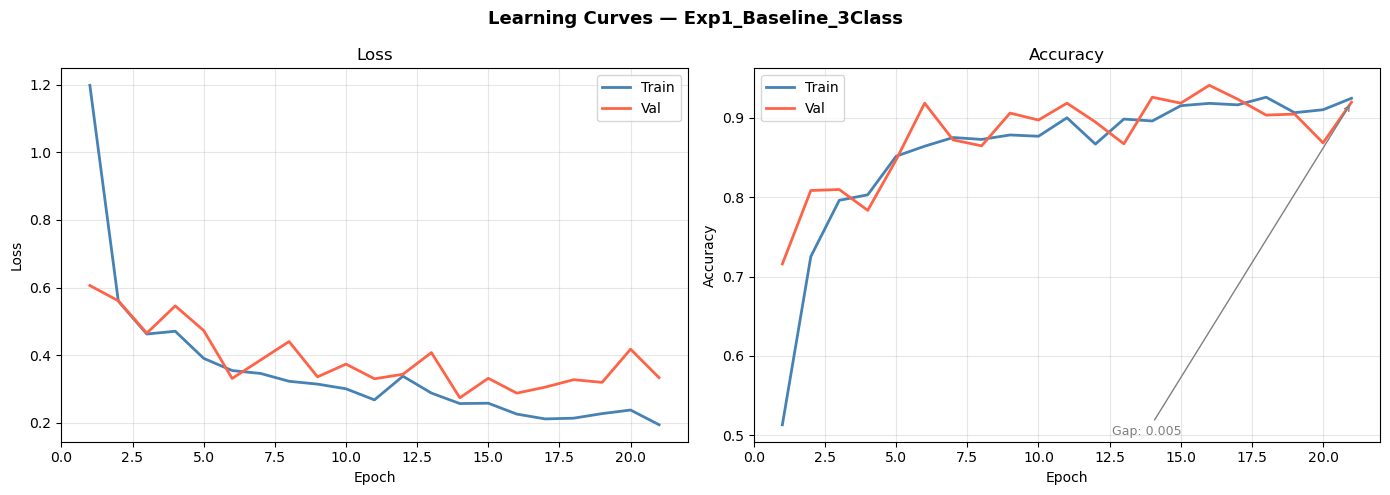

  Saved: results_3class/exp1\Exp1_Baseline_3Class_curves.png

───────────────────────────────────────────────────────
  RESULTS: Exp1_Baseline_3Class
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

         jsn       0.96      0.90      0.93        84
      normal       0.97      0.97      0.97       646
  osteophyte       0.81      0.87      0.84        75

    accuracy                           0.96       805
   macro avg       0.92      0.91      0.91       805
weighted avg       0.96      0.96      0.96       805

  Cohen Kappa : 0.8671
  Macro F1    : 0.9145
  AUC [         jsn]: 0.9659
  AUC [      normal]: 0.9563
  AUC [  osteophyte]: 0.9755


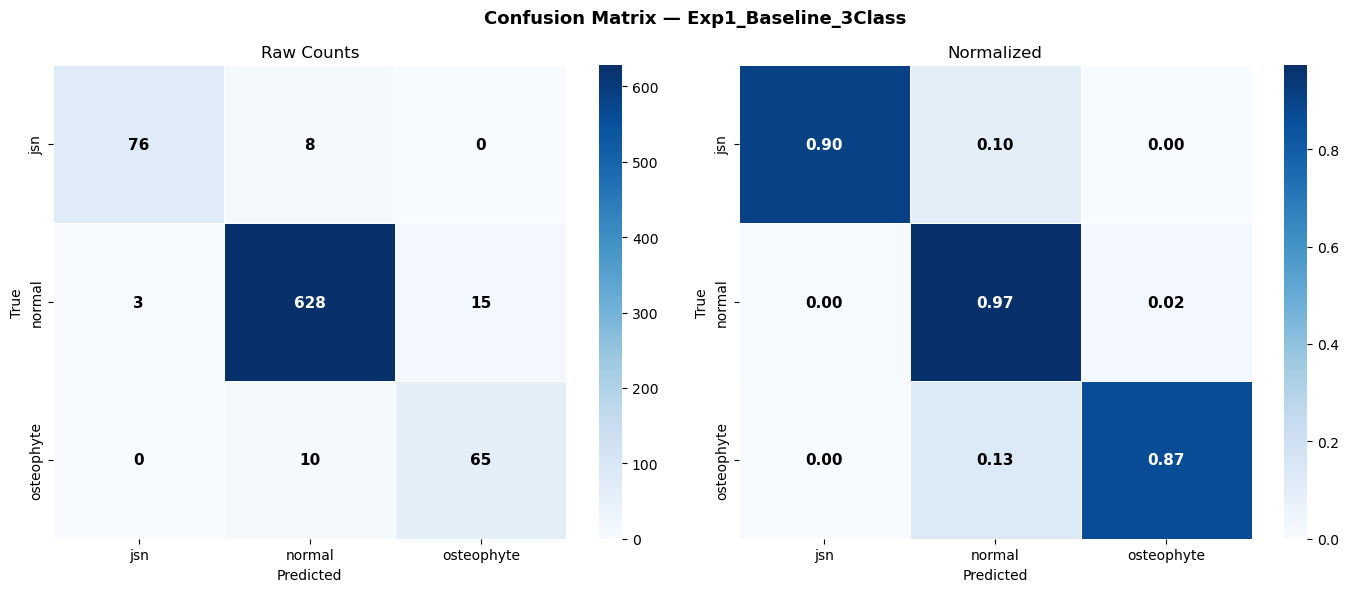

  Saved: results_3class/exp1\Exp1_Baseline_3Class_cm.png

  Exp1 complete.
  Macro F1    : 0.9145
  Cohen Kappa : 0.8671

  ── What to observe ──────────────────────────
  1. Is train acc >> val acc? (overfitting signal)
  2. JSN ↔ Normal confusion? (your KL0/1 problem)
  3. This Macro F1 is your floor to beat


In [6]:
# ══════════════════════════════════════════════════════════════
#  EXPERIMENT 1 — BASELINE CNN (3 classes)
#  Purpose : Establish performance floor
#  Config  : 3 conv blocks | dropout=0.4 | no aug | lr=1e-3
#  Expected: JSN ↔ Normal confusion visible in confusion matrix
#            (KL0 vs KL1 is your hard boundary)
# ══════════════════════════════════════════════════════════════

EXP1_NAME = "Exp1_Baseline_3Class"
EXP1_DIR  = "results_3class/exp1"

train_loader, val_loader, test_loader, class_map = get_loaders(
    train_transform=transform_baseline,
    batch_size=BATCH_SIZE)
weights = compute_class_weights()

model_exp1 = BaselineCNN(num_classes=3, dropout=0.4).to(DEVICE)
criterion  = nn.CrossEntropyLoss(weight=weights)
optimizer  = torch.optim.Adam(
    model_exp1.parameters(), lr=1e-3)

print(f"Exp1 params   : {model_exp1.count_params():,}")
print(f"Class weights : {weights.cpu().numpy().round(3)}")
print(f"Class map     : {class_map}")

history_exp1 = run_training(
    model_exp1, train_loader, val_loader,
    criterion, optimizer,
    save_path=f"{EXP1_DIR}/{EXP1_NAME}_best.pth",
    exp_name=EXP1_NAME
)

model_exp1.load_state_dict(
    torch.load(f"{EXP1_DIR}/{EXP1_NAME}_best.pth",
               map_location=DEVICE))

plot_learning_curves(history_exp1, EXP1_NAME, EXP1_DIR)
results_exp1 = full_evaluate(
    model_exp1, test_loader, EXP1_NAME, EXP1_DIR)
ALL_HISTORIES[EXP1_NAME] = history_exp1

print(f"\n  Exp1 complete.")
print(f"  Macro F1    : {results_exp1['macro_f1']:.4f}")
print(f"  Cohen Kappa : {results_exp1['kappa']:.4f}")
print(f"\n  ── What to observe ──────────────────────────")
print(f"  1. Is train acc >> val acc? (overfitting signal)")
print(f"  2. JSN ↔ Normal confusion? (your KL0/1 problem)")
print(f"  3. This Macro F1 is your floor to beat")


  EXP 2A — Dropout = 0.5  (was 0.4 in Exp1)

  Exp2A_Dropout_3Class
   Epoch |   TrLoss |   TrAcc |   VlLoss |   VlAcc
  -------------------------------------------------------


C:\Users\ASUS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


       1 |   0.9900 |  0.5987 |   0.5879 |  0.8023
       2 |   0.5071 |  0.7552 |   0.4856 |  0.8436
       3 |   0.4566 |  0.8010 |   0.4335 |  0.8836
       4 |   0.4252 |  0.8090 |   0.4301 |  0.8786
       5 |   0.4098 |  0.8590 |   0.4654 |  0.8160
       6 |   0.4040 |  0.8392 |   0.3314 |  0.8999
       7 |   0.3731 |  0.8505 |   0.4002 |  0.8911
       8 |   0.3389 |  0.8748 |   0.3193 |  0.9199
       9 |   0.3396 |  0.8957 |   0.3731 |  0.8748
      10 |   0.3536 |  0.8390 |   0.4411 |  0.8836
      11 |   0.3183 |  0.8935 |   0.3163 |  0.9186
      12 |   0.3004 |  0.9037 |   0.3770 |  0.8886
      13 |   0.2959 |  0.9018 |   0.4575 |  0.8748
      14 |   0.2928 |  0.8890 |   0.3497 |  0.9061
      15 |   0.2724 |  0.9042 |   0.2820 |  0.9249
      16 |   0.2782 |  0.8951 |   0.2918 |  0.9262
      17 |   0.2453 |  0.9278 |   0.3960 |  0.8874
      18 |   0.2305 |  0.9149 |   0.2951 |  0.9337
      19 |   0.2101 |  0.9259 |   0.3453 |  0.9049
      20 |   0.2265 |  0.9275 |

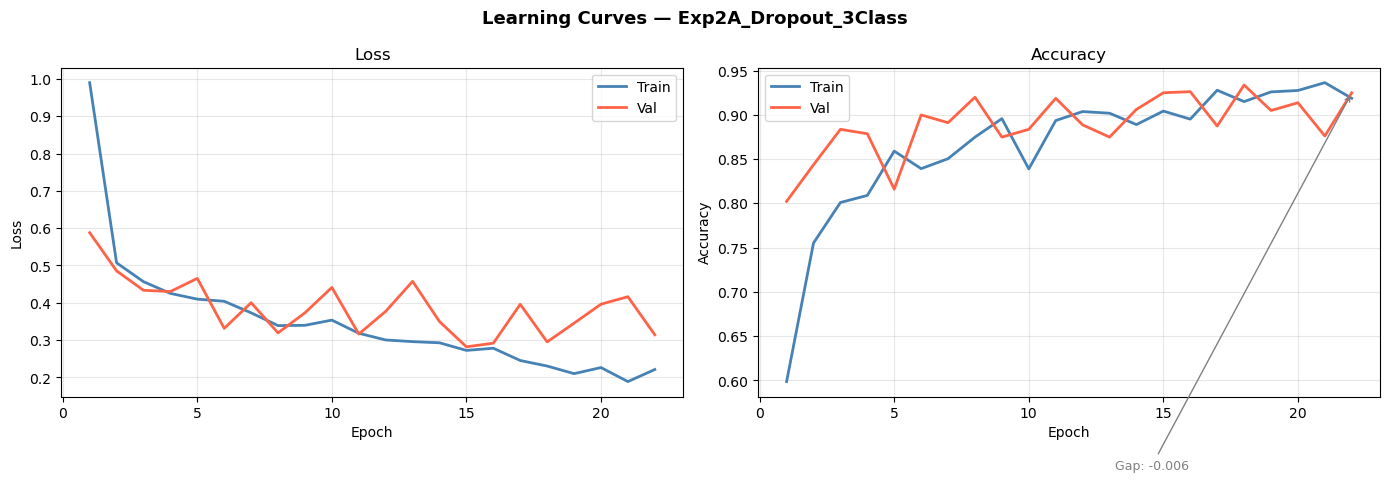

  Saved: results_3class/exp2\Exp2A_Dropout_3Class_curves.png

───────────────────────────────────────────────────────
  RESULTS: Exp2A_Dropout_3Class
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

         jsn       0.88      0.92      0.90        84
      normal       0.97      0.97      0.97       646
  osteophyte       0.86      0.87      0.86        75

    accuracy                           0.95       805
   macro avg       0.90      0.92      0.91       805
weighted avg       0.95      0.95      0.95       805

  Cohen Kappa : 0.8578
  Macro F1    : 0.9087
  AUC [         jsn]: 0.9749
  AUC [      normal]: 0.9664
  AUC [  osteophyte]: 0.9867


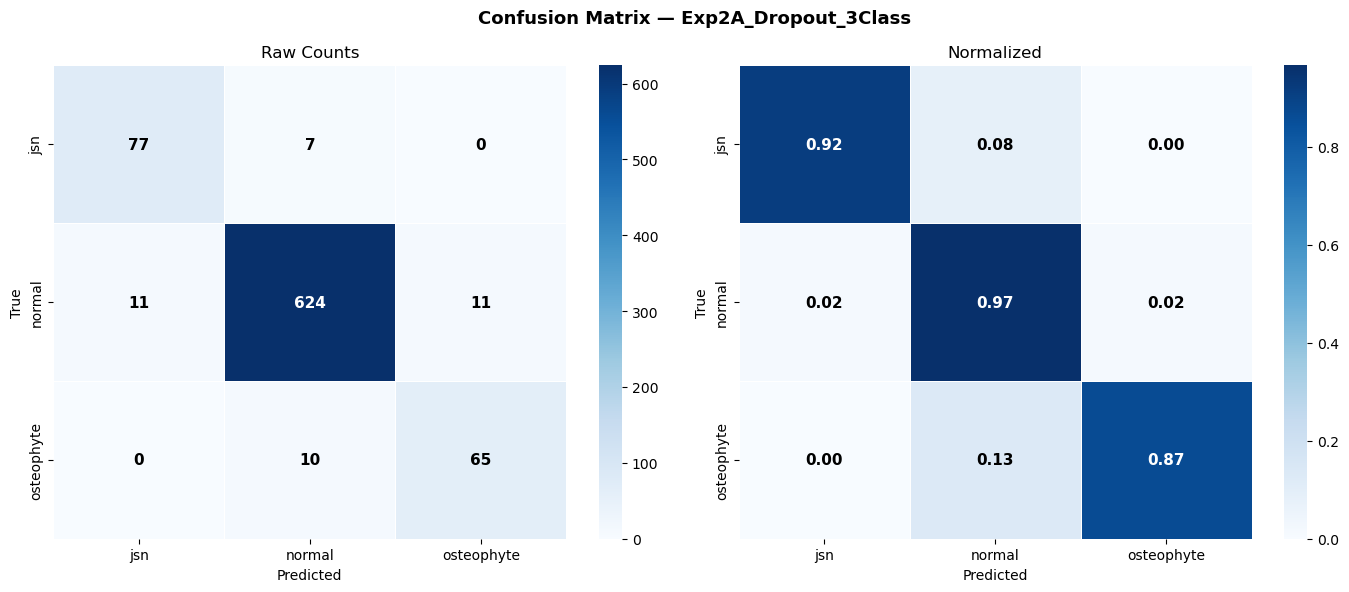

  Saved: results_3class/exp2\Exp2A_Dropout_3Class_cm.png

  EXP 2B — Weight Decay L2 = 1e-4

  Exp2B_WeightDecay_3Class
   Epoch |   TrLoss |   TrAcc |   VlLoss |   VlAcc
  -------------------------------------------------------


C:\Users\ASUS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


       1 |   1.0296 |  0.5358 |   0.4825 |  0.8536
       2 |   0.5258 |  0.7226 |   0.4440 |  0.8210
       3 |   0.4664 |  0.7940 |   0.5368 |  0.7947
       4 |   0.4463 |  0.7873 |   0.5672 |  0.7146
       5 |   0.4070 |  0.8285 |   0.4551 |  0.8248
       6 |   0.3792 |  0.8419 |   0.4337 |  0.8098
       7 |   0.3664 |  0.8456 |   0.3663 |  0.8673
       8 |   0.3145 |  0.8807 |   0.4335 |  0.8611
       9 |   0.2965 |  0.8796 |   0.4086 |  0.8473
      10 |   0.3010 |  0.8716 |   0.5600 |  0.7785
      11 |   0.3070 |  0.8855 |   0.3259 |  0.9074
      12 |   0.2618 |  0.9018 |   0.3964 |  0.9086
      13 |   0.2540 |  0.9114 |   0.3845 |  0.8874
      14 |   0.2408 |  0.9088 |   0.3104 |  0.8961
      15 |   0.2590 |  0.9141 |   0.4502 |  0.8260
      16 |   0.2416 |  0.9123 |   0.3578 |  0.9024
      17 |   0.2246 |  0.9133 |   0.2910 |  0.9412
      18 |   0.2220 |  0.9262 |   0.3040 |  0.9237
      19 |   0.2067 |  0.9213 |   0.3053 |  0.9074
      20 |   0.1853 |  0.9294 |

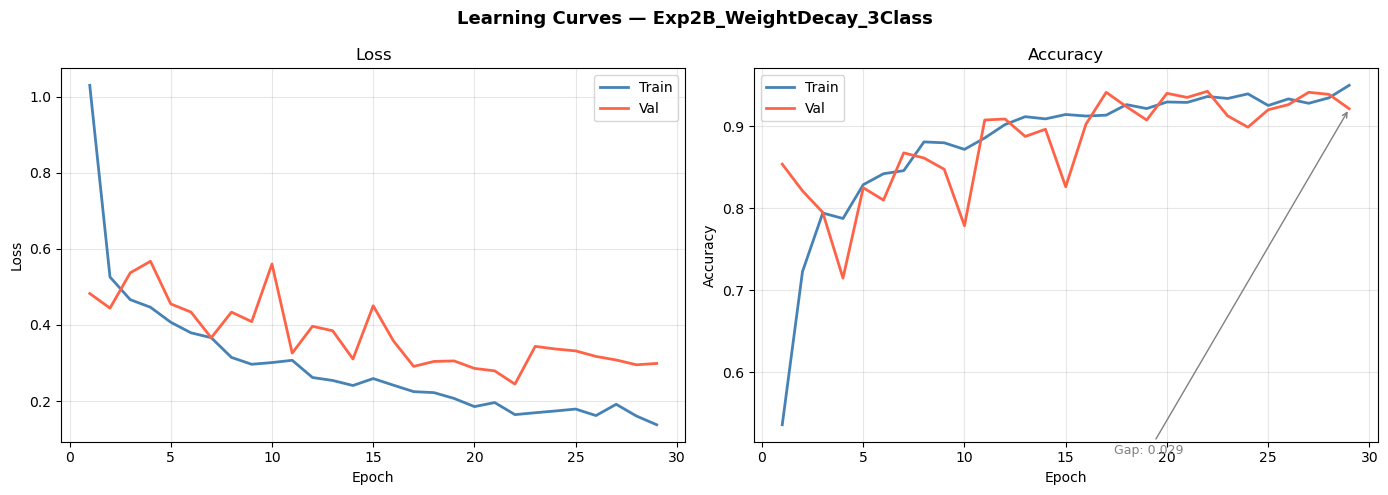

  Saved: results_3class/exp2\Exp2B_WeightDecay_3Class_curves.png

───────────────────────────────────────────────────────
  RESULTS: Exp2B_WeightDecay_3Class
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

         jsn       0.95      0.90      0.93        84
      normal       0.98      0.97      0.97       646
  osteophyte       0.81      0.89      0.85        75

    accuracy                           0.96       805
   macro avg       0.91      0.92      0.92       805
weighted avg       0.96      0.96      0.96       805

  Cohen Kappa : 0.8685
  Macro F1    : 0.9157
  AUC [         jsn]: 0.9794
  AUC [      normal]: 0.9646
  AUC [  osteophyte]: 0.9822


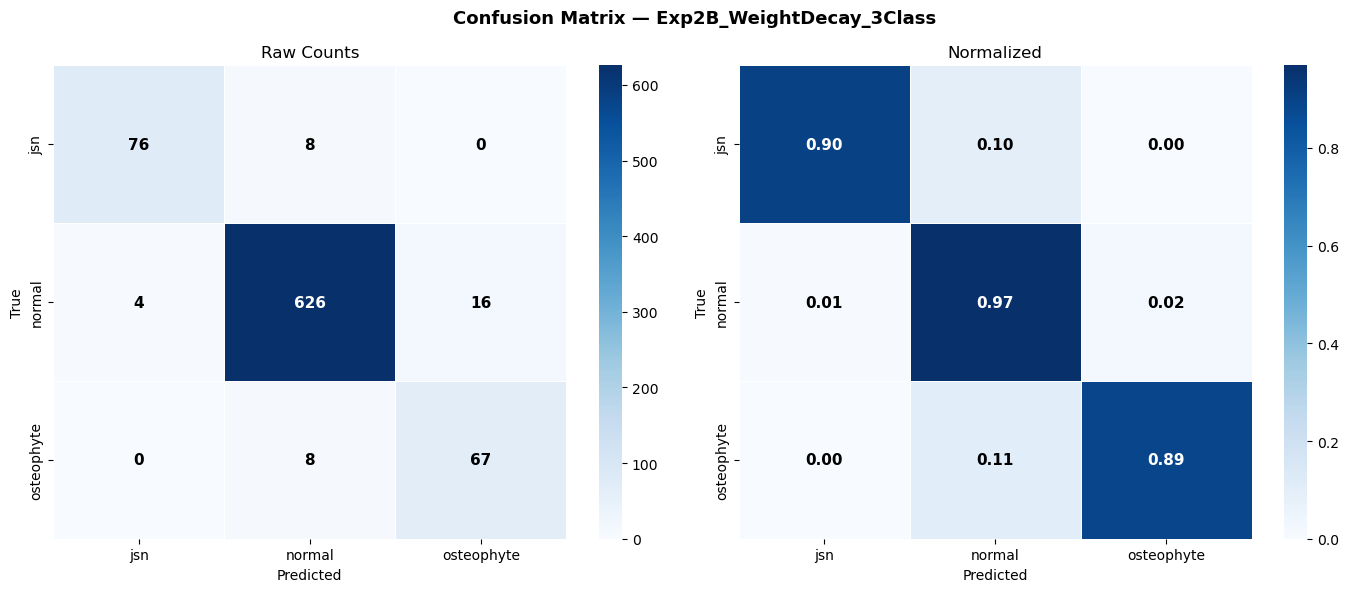

  Saved: results_3class/exp2\Exp2B_WeightDecay_3Class_cm.png

  EXP 2C — Data Augmentation
  Flip + Rotation±5° + Brightness/Contrast jitter

  Exp2C_Augmentation_3Class
   Epoch |   TrLoss |   TrAcc |   VlLoss |   VlAcc
  -------------------------------------------------------


C:\Users\ASUS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


       1 |   1.2106 |  0.4596 |   0.9903 |  0.3329
       2 |   0.6735 |  0.5685 |   0.6250 |  0.7209
       3 |   0.5833 |  0.6779 |   0.5518 |  0.8185
       4 |   0.5141 |  0.7306 |   0.5109 |  0.7960
       5 |   0.5292 |  0.7568 |   0.4289 |  0.8811
       6 |   0.4817 |  0.7838 |   0.5071 |  0.8348
       7 |   0.4762 |  0.7895 |   0.4216 |  0.8723
       8 |   0.4480 |  0.8085 |   0.4526 |  0.8023
       9 |   0.4308 |  0.8175 |   0.3710 |  0.9136
      10 |   0.4228 |  0.8408 |   0.4798 |  0.8736
      11 |   0.4115 |  0.8384 |   0.4414 |  0.8786
      12 |   0.3819 |  0.8668 |   0.4037 |  0.8811
      13 |   0.3792 |  0.8641 |   0.4564 |  0.8210
      14 |   0.3678 |  0.8585 |   0.3690 |  0.8748
      15 |   0.3775 |  0.8585 |   0.3532 |  0.8748
      16 |   0.3748 |  0.8646 |   0.3961 |  0.8824
      17 |   0.3659 |  0.8826 |   0.4053 |  0.8836
      18 |   0.3512 |  0.8727 |   0.4304 |  0.8811
      19 |   0.3421 |  0.8868 |   0.3446 |  0.8936
      20 |   0.3234 |  0.8788 |

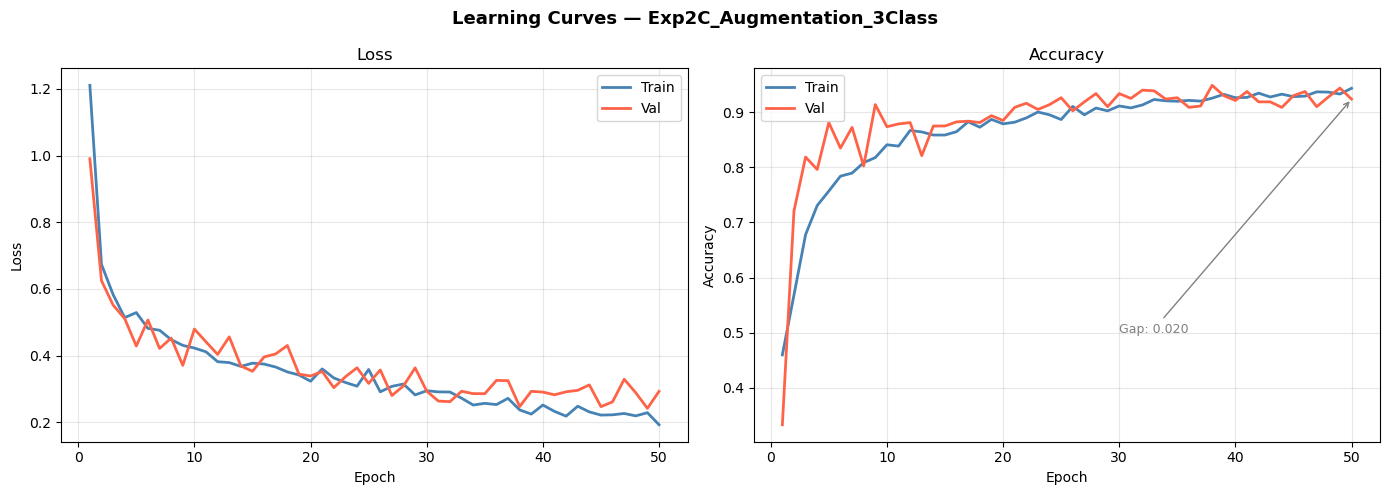

  Saved: results_3class/exp2\Exp2C_Augmentation_3Class_curves.png

───────────────────────────────────────────────────────
  RESULTS: Exp2C_Augmentation_3Class
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

         jsn       0.91      0.92      0.91        84
      normal       0.98      0.96      0.97       646
  osteophyte       0.79      0.92      0.85        75

    accuracy                           0.95       805
   macro avg       0.89      0.93      0.91       805
weighted avg       0.95      0.95      0.95       805

  Cohen Kappa : 0.8607
  Macro F1    : 0.9109
  AUC [         jsn]: 0.9733
  AUC [      normal]: 0.9593
  AUC [  osteophyte]: 0.9792


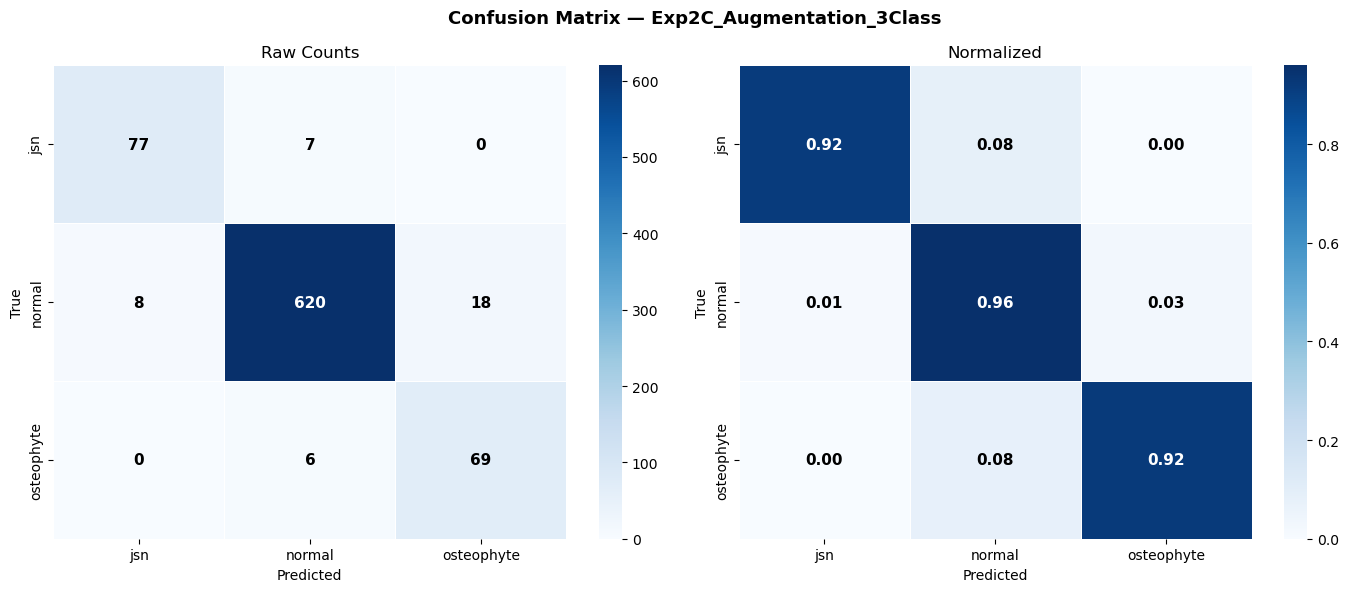

  Saved: results_3class/exp2\Exp2C_Augmentation_3Class_cm.png

════════════════════════════════════════════════════════════
  EXP 2 SUMMARY — 3 CLASS
════════════════════════════════════════════════════════════
  Variant                        Macro F1      Kappa
  --------------------------------------------------
  Exp2A_Dropout_3Class             0.9087     0.8578
  Exp2B_WeightDecay_3Class         0.9157     0.8685
  Exp2C_Augmentation_3Class        0.9109     0.8607

  ✔ Best Exp2 variant : Exp2B_WeightDecay_3Class


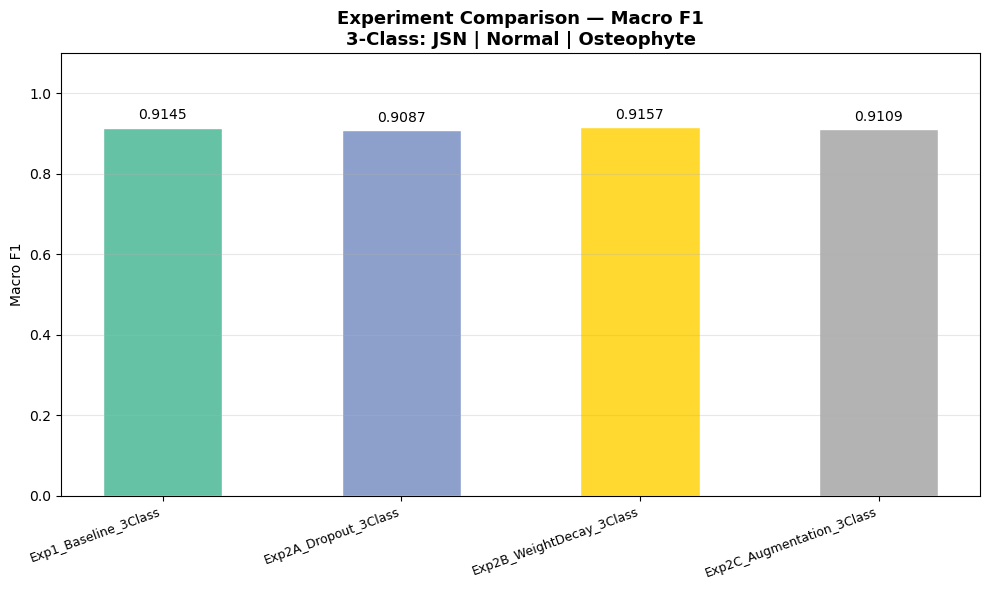

  Saved: results_3class/exp2\comparison_macro_f1.png


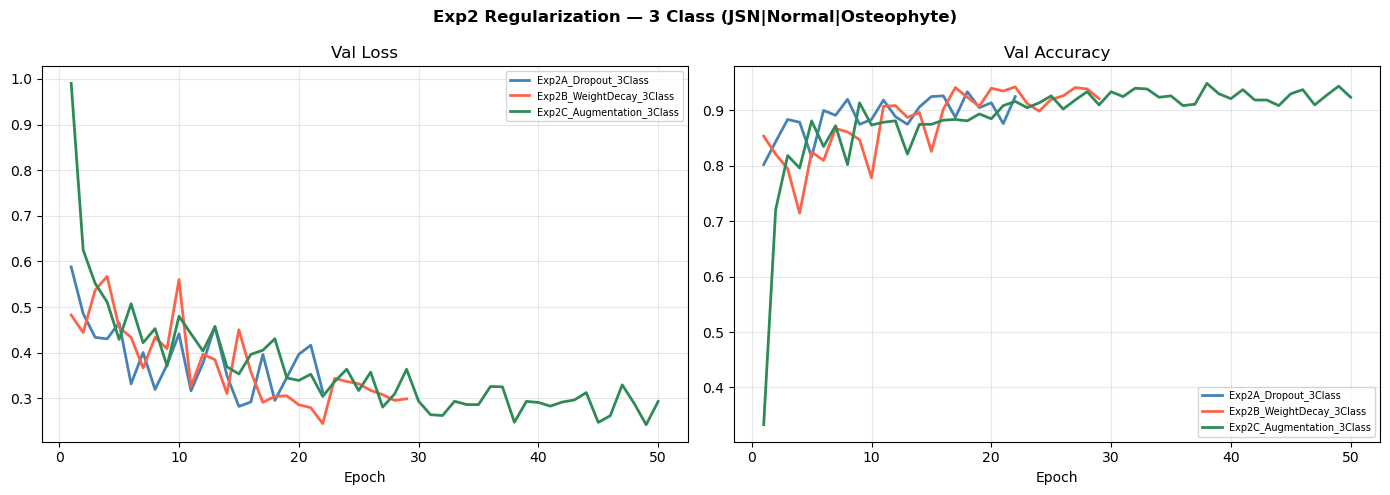

In [7]:
# ══════════════════════════════════════════════════════════════
#  EXPERIMENT 2 — REGULARIZATION STUDY (3 classes)
#  Same BaselineCNN architecture — only training config changes
#  2A: Dropout 0.4 → 0.5
#  2B: Weight Decay L2 = 1e-4
#  2C: Data Augmentation (flip + rotate + jitter)
# ══════════════════════════════════════════════════════════════

exp2_results = {}

def run_exp2_variant(exp_name, model, train_tf,
                      lr=1e-3, wd=0.0, bs=BATCH_SIZE):
    save_dir  = "results_3class/exp2"
    save_path = f"{save_dir}/{exp_name}_best.pth"
    os.makedirs(save_dir, exist_ok=True)

    t_loader, v_loader, te_loader, _ = get_loaders(
        train_transform=train_tf, batch_size=bs)
    w    = compute_class_weights()
    crit = nn.CrossEntropyLoss(weight=w)
    opt  = torch.optim.Adam(
        model.parameters(), lr=lr, weight_decay=wd)

    history = run_training(
        model, t_loader, v_loader, crit, opt,
        save_path=save_path, exp_name=exp_name)
    model.load_state_dict(
        torch.load(save_path, map_location=DEVICE))
    plot_learning_curves(history, exp_name, save_dir)
    results = full_evaluate(model, te_loader, exp_name, save_dir)

    ALL_HISTORIES[exp_name] = history
    exp2_results[exp_name]  = results
    return results, history


# ── 2A: Higher Dropout ─────────────────────────────────────────
print("\n" + "="*60)
print("  EXP 2A — Dropout = 0.5  (was 0.4 in Exp1)")
print("="*60)
model_2a = BaselineCNN(num_classes=3, dropout=0.5).to(DEVICE)
r2a, h2a = run_exp2_variant(
    "Exp2A_Dropout_3Class", model_2a,
    train_tf=transform_baseline)

# ── 2B: Weight Decay ───────────────────────────────────────────
print("\n" + "="*60)
print("  EXP 2B — Weight Decay L2 = 1e-4")
print("="*60)
model_2b = BaselineCNN(num_classes=3, dropout=0.4).to(DEVICE)
r2b, h2b = run_exp2_variant(
    "Exp2B_WeightDecay_3Class", model_2b,
    train_tf=transform_baseline, wd=1e-4)

# ── 2C: Augmentation ───────────────────────────────────────────
print("\n" + "="*60)
print("  EXP 2C — Data Augmentation")
print("  Flip + Rotation±5° + Brightness/Contrast jitter")
print("="*60)
model_2c = BaselineCNN(num_classes=3, dropout=0.4).to(DEVICE)
r2c, h2c = run_exp2_variant(
    "Exp2C_Augmentation_3Class", model_2c,
    train_tf=transform_augmented)

# ── Exp2 Summary ───────────────────────────────────────────────
print("\n" + "═"*60)
print("  EXP 2 SUMMARY — 3 CLASS")
print("═"*60)
print(f"  {'Variant':<28} {'Macro F1':>10} {'Kappa':>10}")
print(f"  {'-'*50}")
for name, res in exp2_results.items():
    print(f"  {name:<28} "
          f"{res['macro_f1']:>10.4f} "
          f"{res['kappa']:>10.4f}")

best_exp2 = max(exp2_results,
                key=lambda k: exp2_results[k]["macro_f1"])
print(f"\n  ✔ Best Exp2 variant : {best_exp2}")

plot_comparison(metric="macro_f1", save_dir="results_3class/exp2")

# ── Overlay val accuracy ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Exp2 Regularization — 3 Class (JSN|Normal|Osteophyte)",
             fontsize=12, fontweight="bold")
colors_map = {
    "Exp2A_Dropout_3Class":    "steelblue",
    "Exp2B_WeightDecay_3Class":"tomato",
    "Exp2C_Augmentation_3Class":"seagreen"
}
for name, hist in [("Exp2A_Dropout_3Class",    h2a),
                    ("Exp2B_WeightDecay_3Class", h2b),
                    ("Exp2C_Augmentation_3Class",h2c)]:
    ep = range(1, len(hist["val_loss"])+1)
    axes[0].plot(ep, hist["val_loss"],
                 label=name, color=colors_map[name], linewidth=2)
    axes[1].plot(ep, hist["val_acc"],
                 label=name, color=colors_map[name], linewidth=2)
for ax, title in zip(axes, ["Val Loss", "Val Accuracy"]):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results_3class/exp2/exp2_overlay.png",
            dpi=150, bbox_inches="tight")
plt.show()

Exp3 augmentation : False
Exp3 weight decay : 0.0001
Exp3 dropout      : 0.4

  EXP 3A — Shallow CNN (2 conv blocks)

  Exp3A_Shallow_3Class
   Epoch |   TrLoss |   TrAcc |   VlLoss |   VlAcc
  -------------------------------------------------------


C:\Users\ASUS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


       1 |   0.8034 |  0.5607 |   0.5393 |  0.6796
       2 |   0.5449 |  0.6918 |   0.4689 |  0.7872
       3 |   0.4910 |  0.7370 |   0.6263 |  0.7534
       4 |   0.4509 |  0.7932 |   0.4158 |  0.8899
       5 |   0.4045 |  0.8269 |   0.4339 |  0.8899
       6 |   0.3839 |  0.8151 |   0.3788 |  0.8636
       7 |   0.3706 |  0.8422 |   0.4987 |  0.8135
       8 |   0.3589 |  0.8521 |   0.4086 |  0.8648
       9 |   0.3312 |  0.8529 |   0.4074 |  0.8748
      10 |   0.3286 |  0.8593 |   0.4290 |  0.8523
      11 |   0.3211 |  0.8617 |   0.3321 |  0.8899
      12 |   0.3060 |  0.8764 |   0.4249 |  0.8886
      13 |   0.2987 |  0.8673 |   0.3476 |  0.9036
      14 |   0.2984 |  0.8783 |   0.3503 |  0.8899
      15 |   0.2807 |  0.8911 |   0.3712 |  0.8773
      16 |   0.2775 |  0.8863 |   0.3218 |  0.9199
      17 |   0.2594 |  0.8909 |   0.3659 |  0.8824
      18 |   0.2547 |  0.8906 |   0.3264 |  0.9149
      19 |   0.2538 |  0.9040 |   0.4001 |  0.8949
      20 |   0.2472 |  0.8954 |

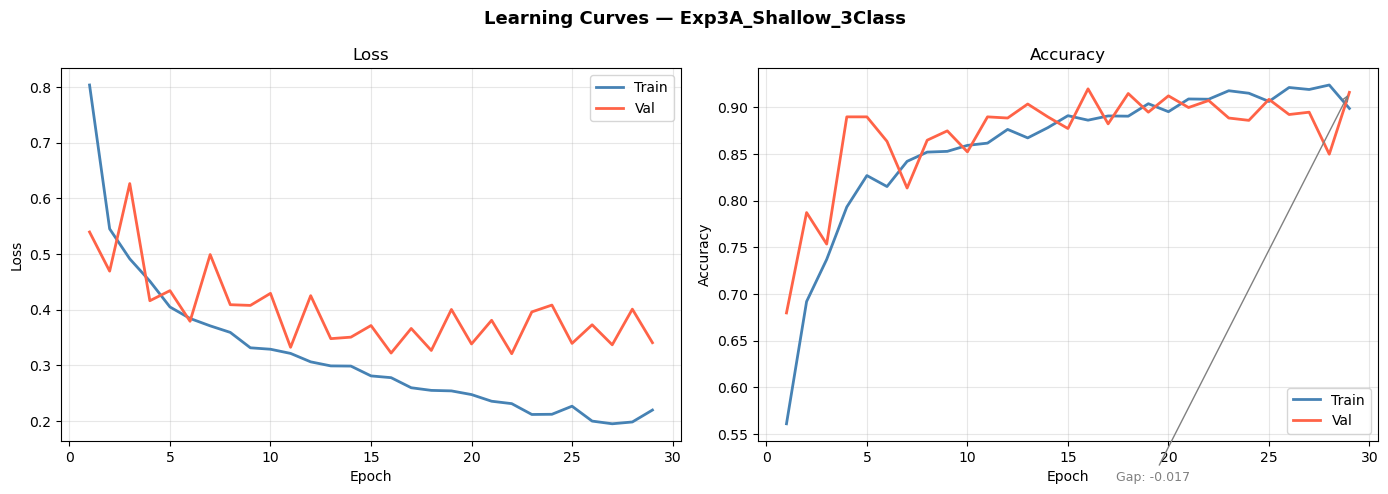

  Saved: results_3class/exp3\Exp3A_Shallow_3Class_curves.png

───────────────────────────────────────────────────────
  RESULTS: Exp3A_Shallow_3Class
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

         jsn       0.84      0.90      0.87        84
      normal       0.97      0.94      0.95       646
  osteophyte       0.71      0.83      0.77        75

    accuracy                           0.93       805
   macro avg       0.84      0.89      0.86       805
weighted avg       0.93      0.93      0.93       805

  Cohen Kappa : 0.7919
  Macro F1    : 0.8645
  AUC [         jsn]: 0.9650
  AUC [      normal]: 0.9482
  AUC [  osteophyte]: 0.9637


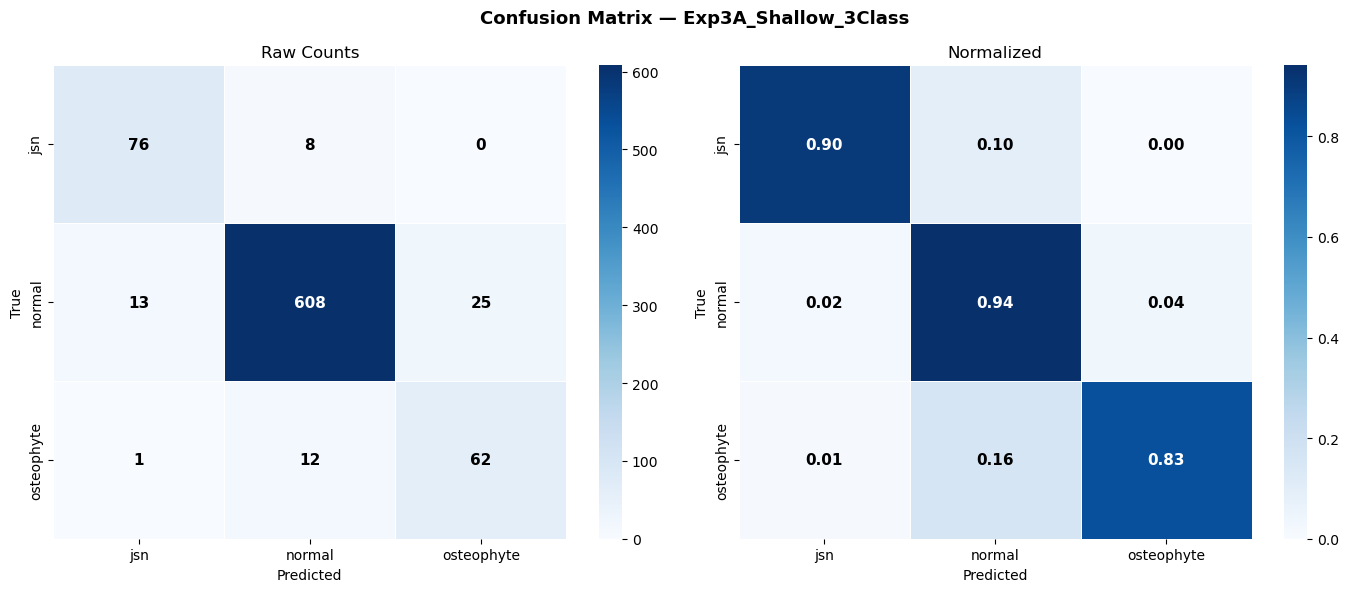

  Saved: results_3class/exp3\Exp3A_Shallow_3Class_cm.png

  EXP 3B — Baseline CNN (3 conv blocks)

  Exp3B_Baseline_3Class
   Epoch |   TrLoss |   TrAcc |   VlLoss |   VlAcc
  -------------------------------------------------------


C:\Users\ASUS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


       1 |   0.9829 |  0.5725 |   0.8061 |  0.5219
       2 |   0.5476 |  0.7563 |   0.5112 |  0.8273
       3 |   0.4940 |  0.7694 |   0.4836 |  0.8636
       4 |   0.4311 |  0.8280 |   0.5573 |  0.8498
       5 |   0.4185 |  0.8224 |   0.4246 |  0.8924
       6 |   0.3832 |  0.8475 |   0.3873 |  0.8761
       7 |   0.3889 |  0.8360 |   0.4037 |  0.8924
       8 |   0.3432 |  0.8470 |   0.2915 |  0.9161
       9 |   0.3497 |  0.8775 |   0.4997 |  0.8498
      10 |   0.3151 |  0.8892 |   0.3960 |  0.8623
      11 |   0.3262 |  0.8844 |   0.3534 |  0.9136
      12 |   0.2969 |  0.8962 |   0.3620 |  0.8999
      13 |   0.3075 |  0.8732 |   0.4606 |  0.8335
      14 |   0.2634 |  0.8997 |   0.3811 |  0.9111
      15 |   0.2834 |  0.8930 |   0.5257 |  0.7760

  Early stopping at epoch 15

  Best Val Acc : 0.9161


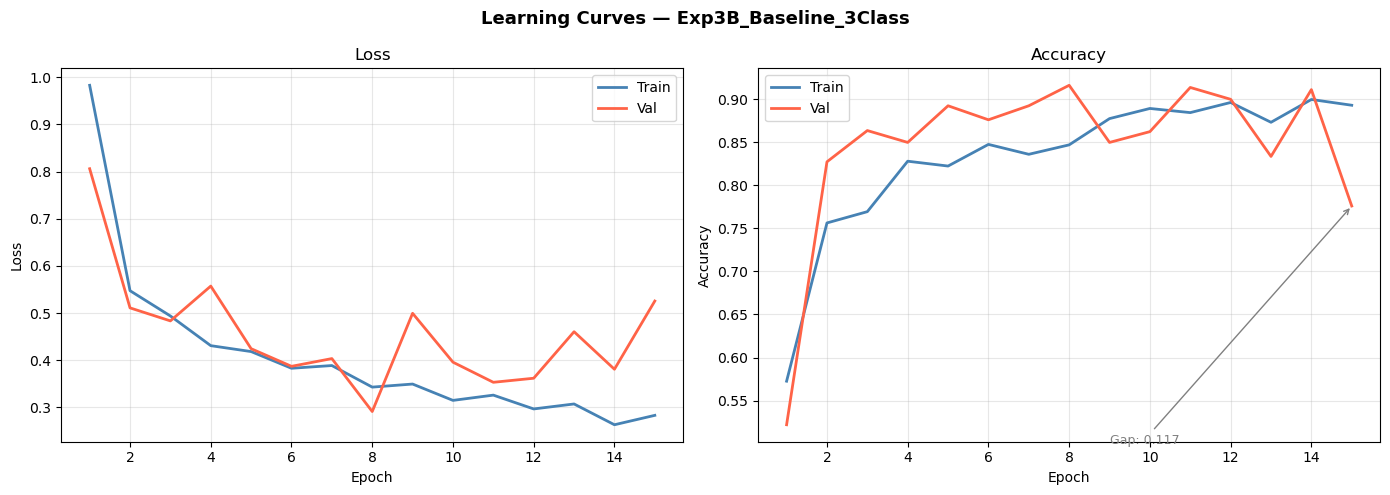

  Saved: results_3class/exp3\Exp3B_Baseline_3Class_curves.png

───────────────────────────────────────────────────────
  RESULTS: Exp3B_Baseline_3Class
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

         jsn       0.95      0.85      0.89        84
      normal       0.96      0.96      0.96       646
  osteophyte       0.74      0.85      0.79        75

    accuracy                           0.94       805
   macro avg       0.88      0.89      0.88       805
weighted avg       0.94      0.94      0.94       805

  Cohen Kappa : 0.8132
  Macro F1    : 0.8812
  AUC [         jsn]: 0.9639
  AUC [      normal]: 0.9382
  AUC [  osteophyte]: 0.9645


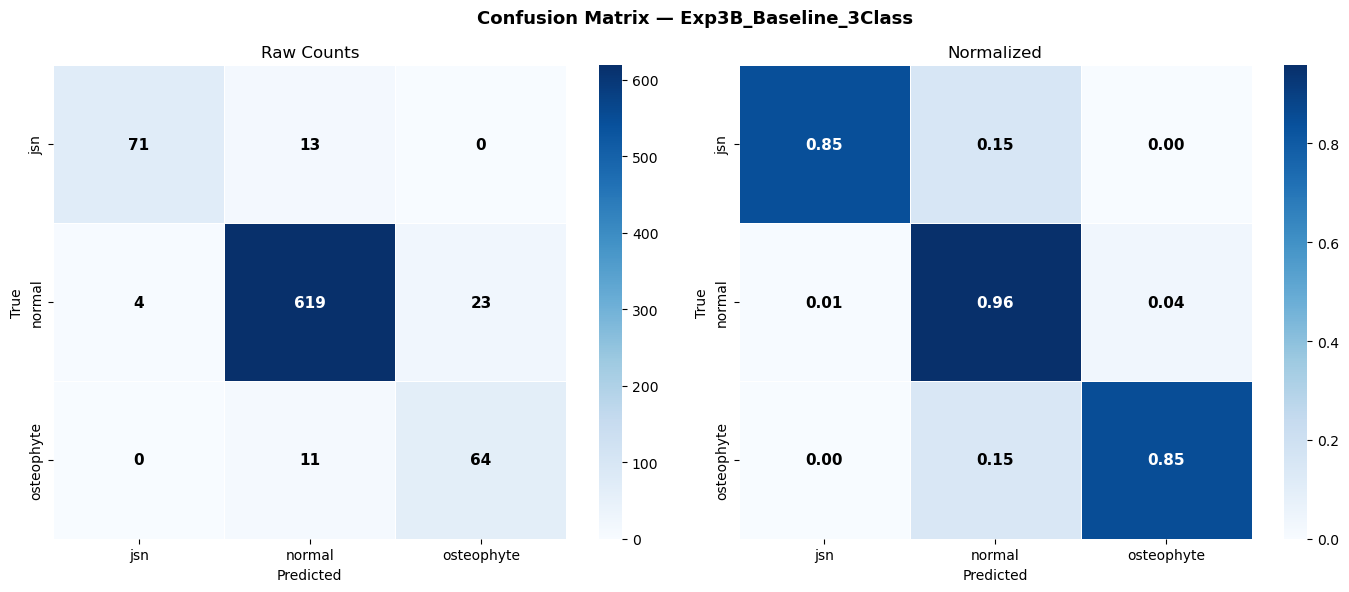

  Saved: results_3class/exp3\Exp3B_Baseline_3Class_cm.png

  EXP 3C — Deep CNN (4 conv blocks)

  Exp3C_Deep_3Class
   Epoch |   TrLoss |   TrAcc |   VlLoss |   VlAcc
  -------------------------------------------------------


C:\Users\ASUS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


       1 |   2.1543 |  0.5270 |   0.7308 |  0.6133
       2 |   0.5349 |  0.7614 |   0.6673 |  0.7009
       3 |   0.4707 |  0.8034 |   0.6140 |  0.7422
       4 |   0.4654 |  0.7932 |   0.4269 |  0.8849
       5 |   0.4004 |  0.8406 |   0.3866 |  0.8974
       6 |   0.4083 |  0.8558 |   0.6215 |  0.6934
       7 |   0.4090 |  0.8309 |   0.3839 |  0.9074
       8 |   0.3619 |  0.8596 |   0.4813 |  0.8698
       9 |   0.3323 |  0.8652 |   0.3464 |  0.9049
      10 |   0.3185 |  0.8844 |   0.3224 |  0.9086
      11 |   0.3260 |  0.8823 |   0.3256 |  0.9036
      12 |   0.2912 |  0.8727 |   0.2707 |  0.9362
      13 |   0.2819 |  0.8973 |   0.3687 |  0.8961
      14 |   0.3186 |  0.8737 |   0.3266 |  0.9036
      15 |   0.2751 |  0.9045 |   0.3421 |  0.8936
      16 |   0.2700 |  0.8989 |   0.4070 |  0.8899
      17 |   0.3369 |  0.8954 |   0.5013 |  0.8623
      18 |   0.2653 |  0.8997 |   0.3724 |  0.9061
      19 |   0.2504 |  0.9104 |   0.4033 |  0.8811

  Early stopping at epoch 19



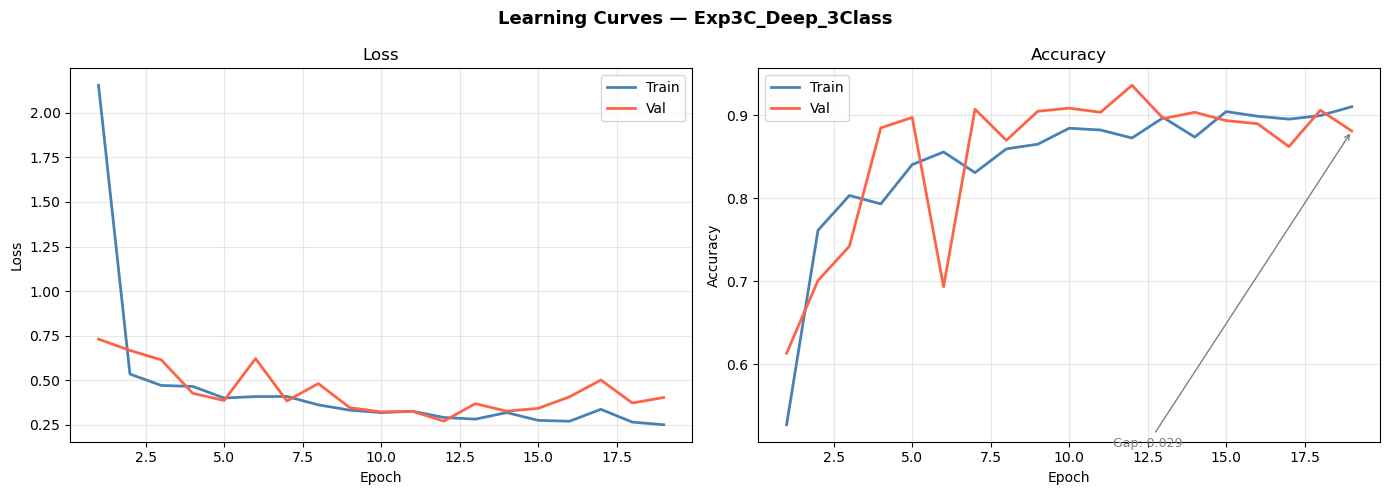

  Saved: results_3class/exp3\Exp3C_Deep_3Class_curves.png

───────────────────────────────────────────────────────
  RESULTS: Exp3C_Deep_3Class
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

         jsn       0.89      0.85      0.87        84
      normal       0.96      0.96      0.96       646
  osteophyte       0.81      0.83      0.82        75

    accuracy                           0.94       805
   macro avg       0.88      0.88      0.88       805
weighted avg       0.94      0.94      0.94       805

  Cohen Kappa : 0.8144
  Macro F1    : 0.8810
  AUC [         jsn]: 0.9686
  AUC [      normal]: 0.9446
  AUC [  osteophyte]: 0.9754


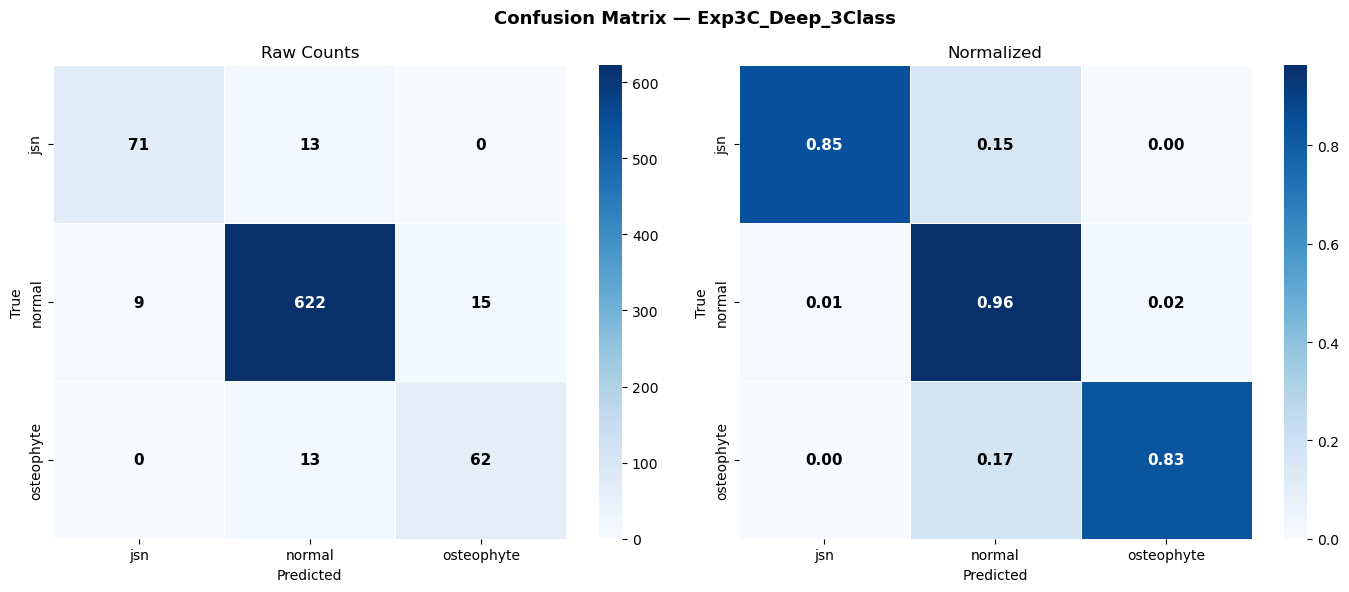

  Saved: results_3class/exp3\Exp3C_Deep_3Class_cm.png

════════════════════════════════════════════════════════════
  EXP 3 SUMMARY — 3 CLASS
════════════════════════════════════════════════════════════
  Variant                          Params   Macro F1    Kappa
  ----------------------------------------------------------
  Exp3A_Shallow_3Class            543,811     0.8645   0.7919
  Exp3B_Baseline_3Class         2,191,299     0.8812   0.8132
  Exp3C_Deep_3Class             8,779,459     0.8810   0.8144

  ✔ Best Exp3 architecture : Exp3B_Baseline_3Class


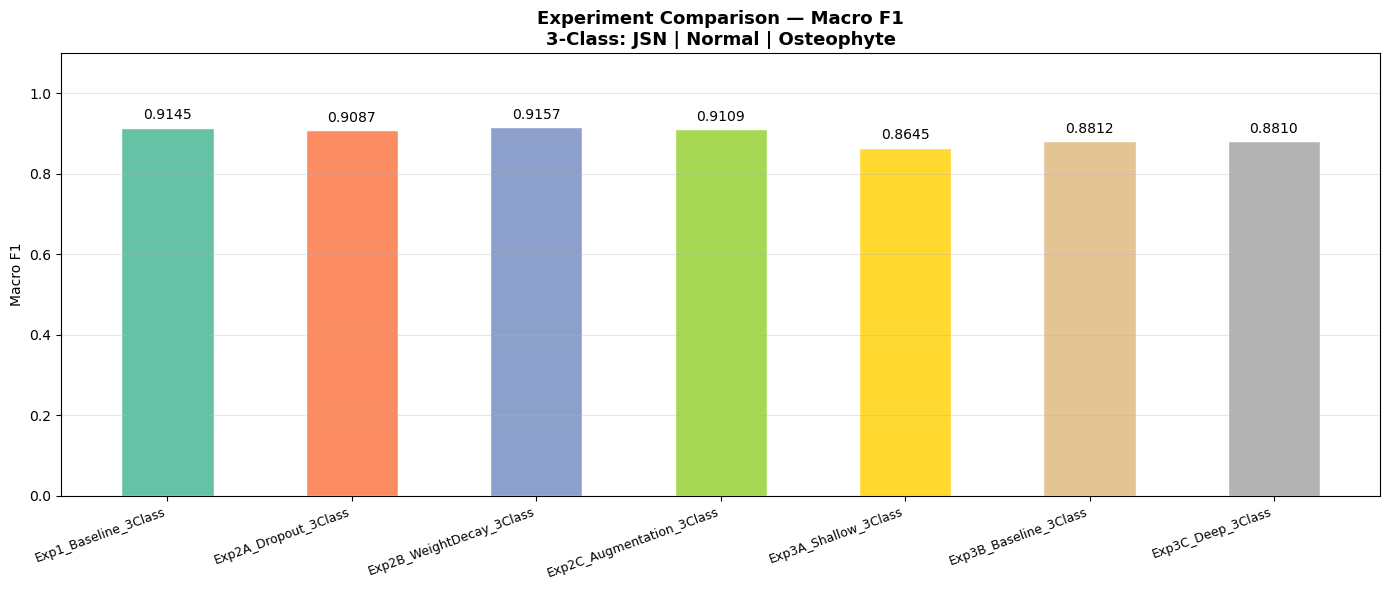

  Saved: results_3class/exp3\comparison_macro_f1.png


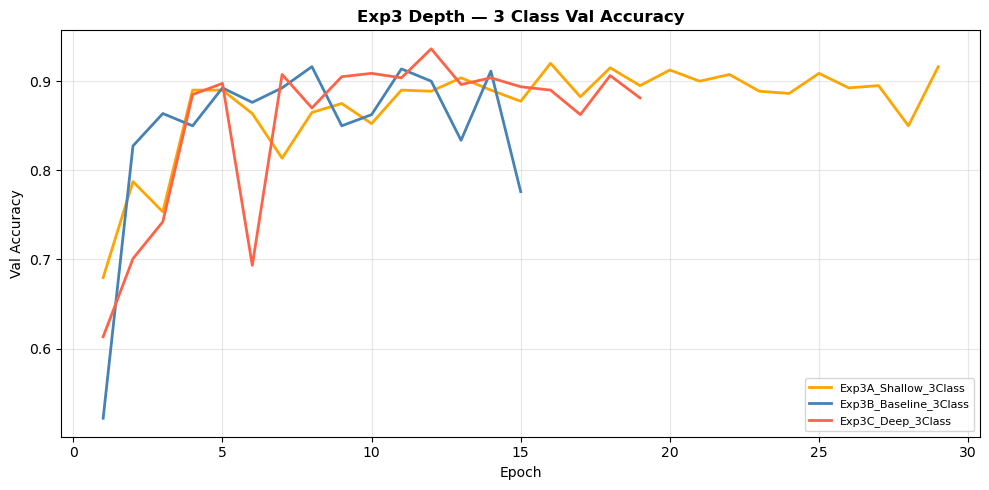

In [8]:
# ══════════════════════════════════════════════════════════════
#  EXPERIMENT 3 — ARCHITECTURE DEPTH (3 classes)
#  Best regularization from Exp2 applied to all variants
#  3A: Shallow  2 conv blocks
#  3B: Baseline 3 conv blocks
#  3C: Deep     4 conv blocks
# ══════════════════════════════════════════════════════════════

USE_AUG = "Augmentation" in best_exp2
USE_WD  = "WeightDecay"  in best_exp2
USE_DR  = 0.5 if "Dropout" in best_exp2 else 0.4

train_tf_exp3 = transform_augmented if USE_AUG \
                else transform_baseline
wd_exp3       = 1e-4 if USE_WD else 0.0

print(f"Exp3 augmentation : {USE_AUG}")
print(f"Exp3 weight decay : {wd_exp3}")
print(f"Exp3 dropout      : {USE_DR}")

exp3_results = {}

def run_exp3_variant(exp_name, model):
    save_dir  = "results_3class/exp3"
    save_path = f"{save_dir}/{exp_name}_best.pth"
    os.makedirs(save_dir, exist_ok=True)

    t_loader, v_loader, te_loader, _ = get_loaders(
        train_transform=train_tf_exp3)
    w    = compute_class_weights()
    crit = nn.CrossEntropyLoss(weight=w)
    opt  = torch.optim.Adam(
        model.parameters(), lr=1e-3, weight_decay=wd_exp3)

    history = run_training(
        model, t_loader, v_loader, crit, opt,
        save_path=save_path, exp_name=exp_name)
    model.load_state_dict(
        torch.load(save_path, map_location=DEVICE))
    plot_learning_curves(history, exp_name, save_dir)
    results = full_evaluate(model, te_loader, exp_name, save_dir)

    ALL_HISTORIES[exp_name] = history
    exp3_results[exp_name]  = results
    return results


# ── 3A: Shallow ────────────────────────────────────────────────
print("\n" + "="*60)
print("  EXP 3A — Shallow CNN (2 conv blocks)")
print("="*60)
model_3a = ShallowCNN(num_classes=3, dropout=USE_DR).to(DEVICE)
r3a = run_exp3_variant("Exp3A_Shallow_3Class", model_3a)

# ── 3B: Baseline ───────────────────────────────────────────────
print("\n" + "="*60)
print("  EXP 3B — Baseline CNN (3 conv blocks)")
print("="*60)
model_3b = BaselineCNN(num_classes=3, dropout=USE_DR).to(DEVICE)
r3b = run_exp3_variant("Exp3B_Baseline_3Class", model_3b)

# ── 3C: Deep ───────────────────────────────────────────────────
print("\n" + "="*60)
print("  EXP 3C — Deep CNN (4 conv blocks)")
print("="*60)
model_3c = DeepCNN(num_classes=3, dropout=USE_DR).to(DEVICE)
r3c = run_exp3_variant("Exp3C_Deep_3Class", model_3c)

# ── Exp3 Summary ───────────────────────────────────────────────
print("\n" + "═"*60)
print("  EXP 3 SUMMARY — 3 CLASS")
print("═"*60)
param_counts = {
    "Exp3A_Shallow_3Class":  ShallowCNN(3).count_params(),
    "Exp3B_Baseline_3Class": BaselineCNN(3).count_params(),
    "Exp3C_Deep_3Class":     DeepCNN(3).count_params()
}
print(f"  {'Variant':<28} {'Params':>10} "
      f"{'Macro F1':>10} {'Kappa':>8}")
print(f"  {'-'*58}")
for name, res in exp3_results.items():
    print(f"  {name:<28} "
          f"{param_counts[name]:>10,} "
          f"{res['macro_f1']:>10.4f} "
          f"{res['kappa']:>8.4f}")

best_exp3 = max(exp3_results,
                key=lambda k: exp3_results[k]["macro_f1"])
print(f"\n  ✔ Best Exp3 architecture : {best_exp3}")

plot_comparison(metric="macro_f1", save_dir="results_3class/exp3")

# ── Overlay val accuracy ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title("Exp3 Depth — 3 Class Val Accuracy",
             fontsize=12, fontweight="bold")
colors3 = {"Exp3A_Shallow_3Class":  "orange",
           "Exp3B_Baseline_3Class": "steelblue",
           "Exp3C_Deep_3Class":     "tomato"}
for name in colors3:
    if name in ALL_HISTORIES:
        hist = ALL_HISTORIES[name]
        ax.plot(range(1, len(hist["val_acc"])+1),
                hist["val_acc"], label=name,
                color=colors3[name], linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Val Accuracy")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results_3class/exp3/exp3_overlay.png",
            dpi=150, bbox_inches="tight")
plt.show()

  EXP 5 — HYPERPARAMETER OPTIMIZATION — 3 CLASS
  Fixed : BaselineCNN + Augmentation
  Vary  : lr | batch_size | dropout | weight_decay

  Total combinations : 81

[  1/81] lr0.01_bs32_dr0.3_wd0.0

  lr0.01_bs32_dr0.3_wd0.0
   Epoch |   TrLoss |   TrAcc |   VlLoss |   VlAcc
  -------------------------------------------------------


C:\Users\ASUS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


       1 |   3.5258 |  0.4599 |   0.9599 |  0.5294
       2 |   0.8760 |  0.5674 |   0.8686 |  0.6283
       3 |   0.8097 |  0.6501 |   0.7133 |  0.7835
       4 |   0.9034 |  0.6755 |   0.6501 |  0.8423
       5 |   0.6896 |  0.7132 |   0.7476 |  0.7284
       6 |   0.7378 |  0.7287 |   0.7499 |  0.7697
       7 |   0.7095 |  0.7242 |   0.7376 |  0.7021
       8 |   0.6449 |  0.7512 |   0.6009 |  0.8135
       9 |   0.6151 |  0.7774 |   0.5925 |  0.8498
      10 |   0.7060 |  0.7731 |   0.7366 |  0.7209
      11 |   0.6280 |  0.7646 |   0.5910 |  0.8348
      12 |   0.5929 |  0.7838 |   0.7124 |  0.7109
      13 |   0.6110 |  0.7980 |   0.6054 |  0.8398
      14 |   0.5670 |  0.8146 |   0.5946 |  0.8148
      15 |   0.5917 |  0.8095 |   0.4782 |  0.8586
      16 |   0.5271 |  0.8296 |   0.4666 |  0.8773
      17 |   0.5492 |  0.8242 |   0.4765 |  0.8673
      18 |   0.5523 |  0.8018 |   0.4812 |  0.8824
      19 |   0.4689 |  0.8293 |   0.5411 |  0.7847
      20 |   0.5035 |  0.8320 |

C:\Users\ASUS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


       1 |   3.5713 |  0.5013 |   1.0888 |  0.2315
       2 |   0.9411 |  0.4992 |   0.9039 |  0.6971
       3 |   0.8530 |  0.6188 |   0.9419 |  0.6258
       4 |   0.8431 |  0.6768 |   0.6651 |  0.8073
       5 |   0.8600 |  0.7044 |   0.8937 |  0.6270
       6 |   0.8284 |  0.7044 |   0.8665 |  0.6220
       7 |   0.8846 |  0.7349 |   0.9686 |  0.6370
       8 |   0.8628 |  0.7170 |   0.7292 |  0.7985
       9 |   0.7768 |  0.7234 |   0.7358 |  0.7497
      10 |   0.8408 |  0.7397 |   0.8070 |  0.6308
      11 |   0.8264 |  0.7154 |   0.7447 |  0.7822

  Early stopping at epoch 11

  Best Val Acc : 0.8073
  Val Macro F1 : 0.6689 | Kappa : 0.4662

[  3/81] lr0.01_bs32_dr0.3_wd0.001

  lr0.01_bs32_dr0.3_wd0.001
   Epoch |   TrLoss |   TrAcc |   VlLoss |   VlAcc
  -------------------------------------------------------


...

       1 |   0.9085 |  0.4716 |   0.8480 |  0.8060
       2 |   0.7070 |  0.6150 |   0.5987 |  0.7572
       3 |   0.5686 |  0.7014 |   0.6201 |  0.6621
       4 |   0.5156 |  0.7314 |   0.4909 |  0.7910
       5 |   0.5084 |  0.7600 |   0.4894 |  0.7760
       6 |   0.4800 |  0.7662 |   0.4644 |  0.8135
       7 |   0.4575 |  0.7956 |   0.4203 |  0.8711
       8 |   0.4343 |  0.7983 |   0.4202 |  0.8623
       9 |   0.3937 |  0.8395 |   0.3619 |  0.8874
      10 |   0.4007 |  0.8408 |   0.4104 |  0.8673
      11 |   0.3817 |  0.8398 |   0.3411 |  0.9237
      12 |   0.3813 |  0.8526 |   0.4036 |  0.8548
      13 |   0.3954 |  0.8654 |   0.3934 |  0.8798
      14 |   0.3571 |  0.8596 |   0.3701 |  0.8811
      15 |   0.3320 |  0.8727 |   0.3369 |  0.9049
      16 |   0.3478 |  0.8753 |   0.3335 |  0.9237
      17 |   0.3462 |  0.8633 |   0.3278 |  0.9024
      18 |   0.3336 |  0.8777 |   0.3536 |  0.8748
      19 |   0.3476 |  0.8868 |   0.3729 |  0.8786
      20 |   0.3261 |  0.8593 |

C:\Users\ASUS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


       1 |   0.8433 |  0.4658 |   0.7623 |  0.8198
       2 |   0.6393 |  0.6482 |   0.5301 |  0.7422
       3 |   0.5301 |  0.7143 |   0.4868 |  0.8210
       4 |   0.5031 |  0.7603 |   0.4860 |  0.7885
       5 |   0.4709 |  0.7782 |   0.4692 |  0.8461
       6 |   0.4547 |  0.7879 |   0.3853 |  0.8748
       7 |   0.4311 |  0.8178 |   0.4101 |  0.8999
       8 |   0.4699 |  0.8293 |   0.4287 |  0.8335
       9 |   0.4261 |  0.8344 |   0.4065 |  0.8899
      10 |   0.3974 |  0.8398 |   0.3986 |  0.8498
      11 |   0.3880 |  0.8456 |   0.3487 |  0.9161
      12 |   0.3587 |  0.8547 |   0.3565 |  0.8824
      13 |   0.3658 |  0.8772 |   0.3971 |  0.8486
      14 |   0.3661 |  0.8505 |   0.3388 |  0.9086
      15 |   0.3610 |  0.8716 |   0.3907 |  0.8899
      16 |   0.3350 |  0.8745 |   0.3278 |  0.9124
      17 |   0.3460 |  0.8735 |   0.3538 |  0.8999
      18 |   0.3286 |  0.8917 |   0.3540 |  0.8849
      19 |   0.3569 |  0.8799 |   0.3607 |  0.8811
      20 |   0.3303 |  0.8844 |

C:\Users\ASUS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


       1 |   0.8888 |  0.4478 |   0.8562 |  0.7547
       2 |   0.6733 |  0.6094 |   0.5879 |  0.7347
       3 |   0.5523 |  0.6958 |   0.4711 |  0.8010
       4 |   0.4906 |  0.7657 |   0.4604 |  0.7910
       5 |   0.4662 |  0.7707 |   0.4635 |  0.7860
       6 |   0.4820 |  0.7777 |   0.3984 |  0.8798
       7 |   0.4627 |  0.7828 |   0.4100 |  0.8648
       8 |   0.4211 |  0.8044 |   0.3722 |  0.8849
       9 |   0.3917 |  0.8283 |   0.3968 |  0.8786
      10 |   0.3793 |  0.8617 |   0.3516 |  0.9036
      11 |   0.3726 |  0.8486 |   0.3472 |  0.8961
      12 |   0.3666 |  0.8676 |   0.3728 |  0.8736
      13 |   0.3494 |  0.8673 |   0.3567 |  0.9061
      14 |   0.3494 |  0.8604 |   0.3510 |  0.8924
      15 |   0.3616 |  0.8593 |   0.4232 |  0.8461
      16 |   0.3500 |  0.8638 |   0.3506 |  0.8773
      17 |   0.3441 |  0.8654 |   0.3544 |  0.8899
      18 |   0.3212 |  0.8804 |   0.3590 |  0.8886

  Early stopping at epoch 18

  Best Val Acc : 0.9061
  Val Macro F1 : 0.8303 | K

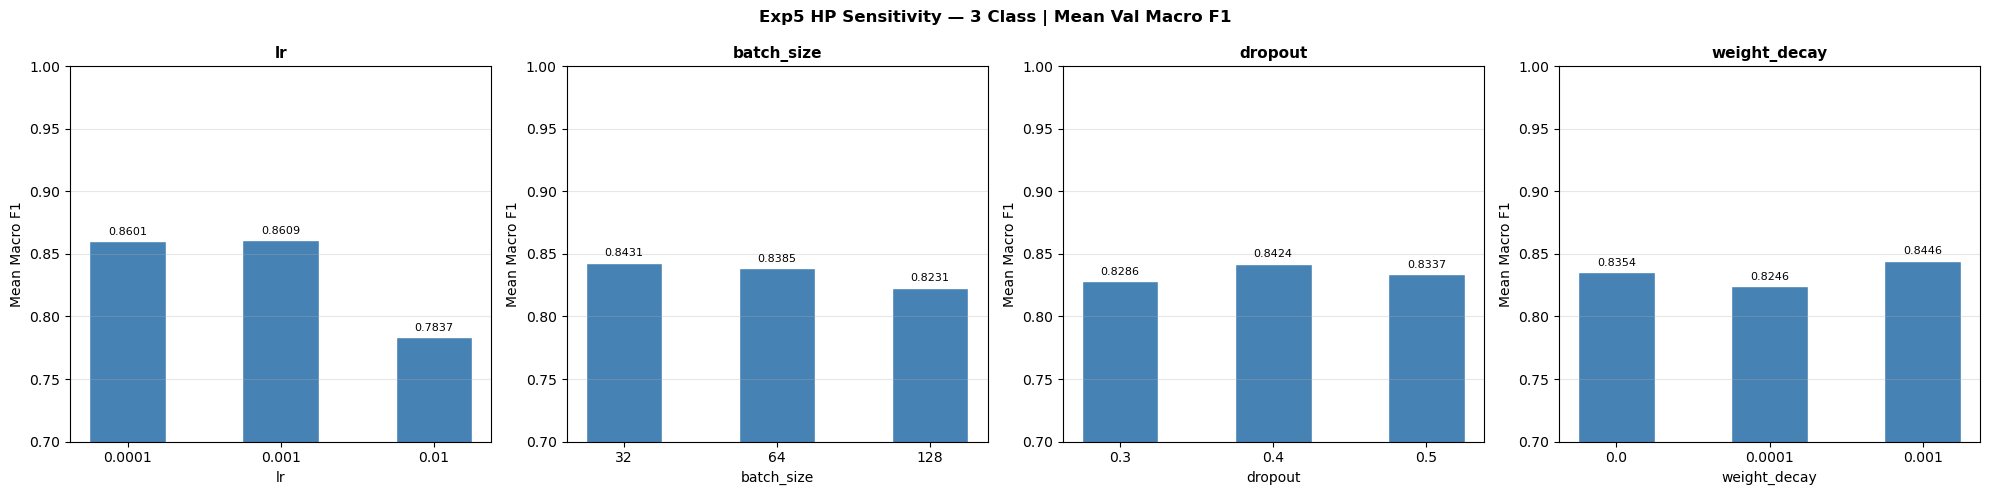

In [7]:
# ══════════════════════════════════════════════════════════════
#  EXPERIMENT 5 — HYPERPARAMETER OPTIMIZATION (3 classes)
#  Base   : BaselineCNN + best regularization from Exp2
#  Varies : lr × batch_size × dropout × weight_decay
#  81 combinations | val Macro F1 as selection metric
# ══════════════════════════════════════════════════════════════

import itertools
import pandas as pd

os.makedirs("results_3class/exp5", exist_ok=True)

print("="*65)
print("  EXP 5 — HYPERPARAMETER OPTIMIZATION — 3 CLASS")
print("  Fixed : BaselineCNN + Augmentation")
print("  Vary  : lr | batch_size | dropout | weight_decay")
print("="*65)

param_grid = {
    "lr":           [1e-2, 1e-3, 1e-4],
    "batch_size":   [32, 64, 128],
    "dropout":      [0.3, 0.4, 0.5],
    "weight_decay": [0.0, 1e-4, 1e-3]
}

all_combinations = list(itertools.product(
    param_grid["lr"],
    param_grid["batch_size"],
    param_grid["dropout"],
    param_grid["weight_decay"]
))
print(f"\n  Total combinations : {len(all_combinations)}")

best_f1      = 0.0
best_params  = {}
hp_summary   = []

for idx, (lr, bs, dr, wd) in enumerate(all_combinations):
    run_name = f"lr{lr}_bs{bs}_dr{dr}_wd{wd}"
    print(f"\n[{idx+1:3d}/{len(all_combinations)}] {run_name}")

    t_loader, v_loader, te_loader, _ = get_loaders(
        train_transform=transform_augmented, batch_size=bs)
    w    = compute_class_weights()
    crit = nn.CrossEntropyLoss(weight=w)

    model_hp = BaselineCNN(num_classes=3, dropout=dr).to(DEVICE)
    opt      = torch.optim.Adam(
        model_hp.parameters(), lr=lr, weight_decay=wd)

    history_hp = run_training(
        model_hp, t_loader, v_loader, crit, opt,
        save_path=f"results_3class/exp5/{run_name}_best.pth",
        exp_name=run_name,
        epochs=30)

    model_hp.load_state_dict(
        torch.load(
            f"results_3class/exp5/{run_name}_best.pth",
            map_location=DEVICE))
    model_hp.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in v_loader:
            logits = model_hp(x.to(DEVICE))
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())

    val_f1    = f1_score(all_labels, all_preds,
                          average="macro")
    val_kappa = cohen_kappa_score(all_labels, all_preds)

    hp_summary.append({
        "run":          run_name,
        "lr":           lr,
        "batch_size":   bs,
        "dropout":      dr,
        "weight_decay": wd,
        "val_macro_f1": val_f1,
        "val_kappa":    val_kappa
    })

    print(f"  Val Macro F1 : {val_f1:.4f} | "
          f"Kappa : {val_kappa:.4f}", end="")

    if val_f1 > best_f1:
        best_f1     = val_f1
        best_params = {"lr":lr, "bs":bs, "dr":dr, "wd":wd}
        torch.save(model_hp.state_dict(),
                   "results_3class/exp5/BEST_HP_model.pth")
        print("  ★ New best!")
    else:
        print()

# ── Save and plot ──────────────────────────────────────────────
df_hp = pd.DataFrame(hp_summary)
df_hp.to_csv("results_3class/exp5/hp_summary.csv", index=False)

print(f"\n  ✔ Best params : {best_params}")
print(f"  ✔ Best Val F1 : {best_f1:.4f}")
print(f"\n  Top 10:")
print(df_hp.sort_values("val_macro_f1", ascending=False)
          .head(10).to_string(index=False))

# ── HP Sensitivity Plot ────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    "Exp5 HP Sensitivity — 3 Class | Mean Val Macro F1",
    fontsize=12, fontweight="bold")

for ax, param in zip(axes,
    ["lr","batch_size","dropout","weight_decay"]):
    grouped = df_hp.groupby(param)["val_macro_f1"]\
                   .mean().reset_index()
    bars = ax.bar(grouped[param].astype(str),
                  grouped["val_macro_f1"],
                  color="steelblue", edgecolor="white",
                  width=0.5)
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
    ax.set_title(param, fontsize=11, fontweight="bold")
    ax.set_xlabel(param)
    ax.set_ylabel("Mean Macro F1")
    ax.set_ylim(0.7, 1.0)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results_3class/exp5/hp_sensitivity.png",
            dpi=150, bbox_inches="tight")
plt.show()

  FINAL MODEL — 3 CLASS (JSN | Normal | Osteophyte)
  lr=0.001 | bs=32 | dr=0.3 | wd=0.001

  Final_Model_3Class
   Epoch |   TrLoss |   TrAcc |   VlLoss |   VlAcc
  -------------------------------------------------------


C:\Users\ASUS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


       1 |   1.0478 |  0.5527 |   0.5701 |  0.7897
       2 |   0.5633 |  0.7108 |   0.7090 |  0.5757
       3 |   0.5123 |  0.7798 |   0.5417 |  0.7860
       4 |   0.4964 |  0.7809 |   0.6012 |  0.7885
       5 |   0.4273 |  0.8352 |   0.4153 |  0.8573
       6 |   0.4341 |  0.8373 |   0.4534 |  0.8623
       7 |   0.4317 |  0.8317 |   0.4915 |  0.8411
       8 |   0.3984 |  0.8523 |   0.4895 |  0.8436
       9 |   0.3793 |  0.8657 |   0.4157 |  0.8698
      10 |   0.3818 |  0.8705 |   0.3777 |  0.9024
      11 |   0.3505 |  0.8863 |   0.4699 |  0.8398
      12 |   0.3749 |  0.8743 |   0.3558 |  0.9099
      13 |   0.3305 |  0.8852 |   0.3628 |  0.8999
      14 |   0.3395 |  0.8887 |   0.2868 |  0.9124
      15 |   0.3307 |  0.8900 |   0.3254 |  0.9086
      16 |   0.3340 |  0.8906 |   0.2858 |  0.9111
      17 |   0.3286 |  0.8911 |   0.4182 |  0.8711
      18 |   0.3276 |  0.8922 |   0.3960 |  0.8849
      19 |   0.3088 |  0.9032 |   0.3101 |  0.9149
      20 |   0.3029 |  0.9136 |

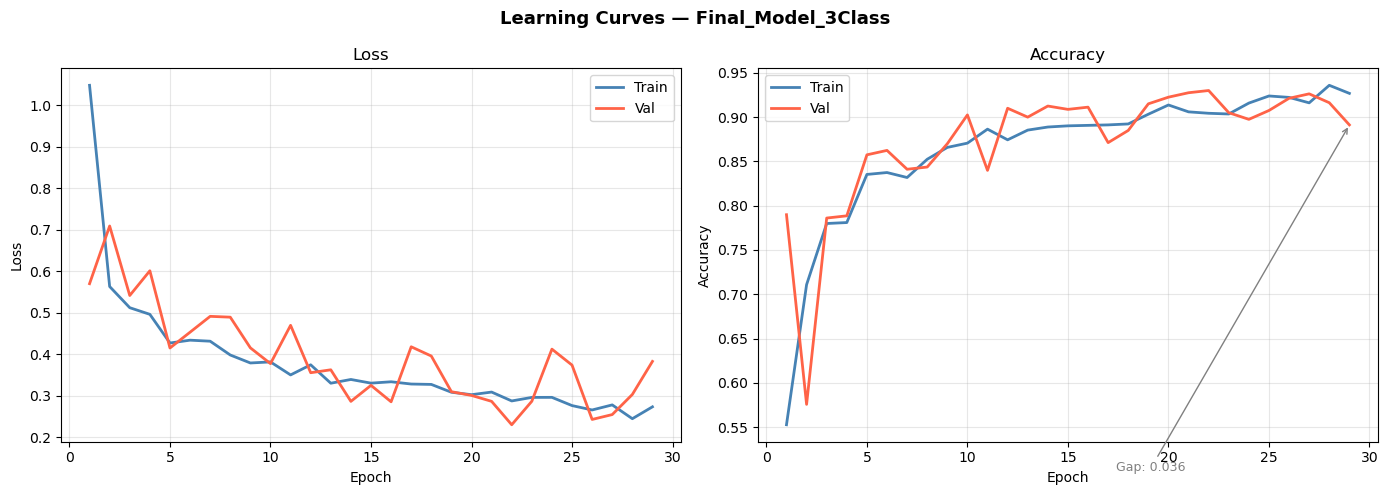

  Saved: results_3class/final\Final_Model_3Class_curves.png

───────────────────────────────────────────────────────
  RESULTS: Final_Model_3Class
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

         jsn       0.89      0.83      0.86        84
      normal       0.97      0.96      0.96       646
  osteophyte       0.80      0.88      0.84        75

    accuracy                           0.94       805
   macro avg       0.89      0.89      0.89       805
weighted avg       0.94      0.94      0.94       805

  Cohen Kappa : 0.8274
  Macro F1    : 0.8880
  AUC [         jsn]: 0.9672
  AUC [      normal]: 0.9519
  AUC [  osteophyte]: 0.9785


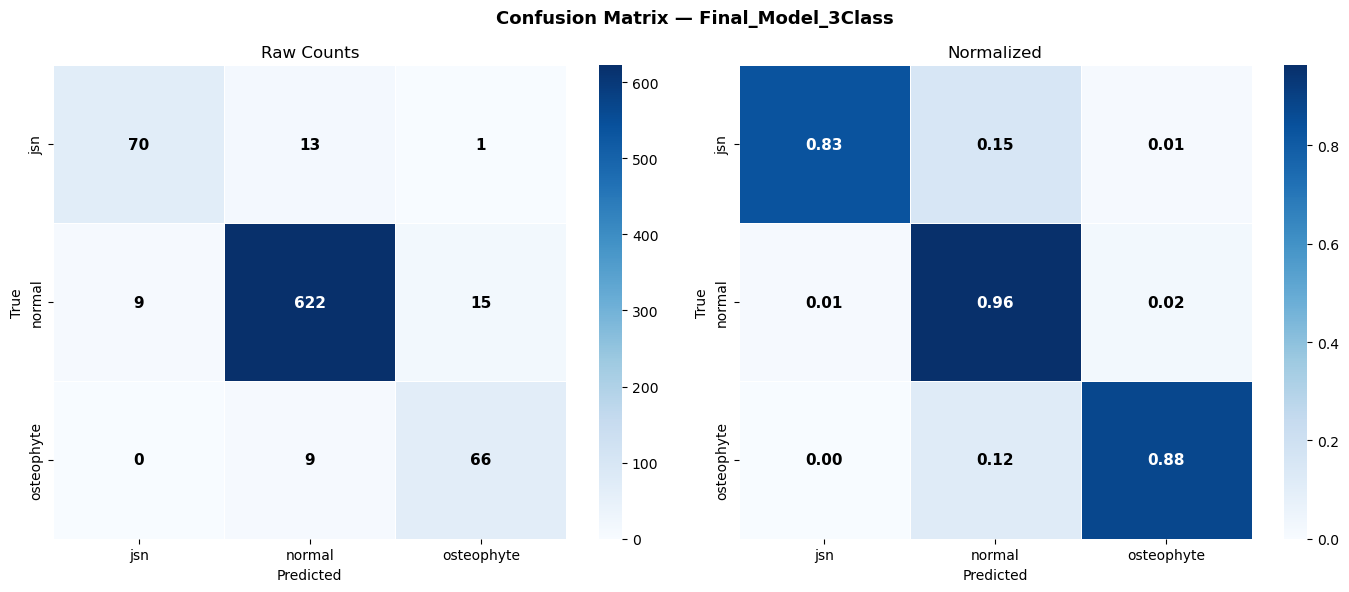

  Saved: results_3class/final\Final_Model_3Class_cm.png

═════════════════════════════════════════════════════════════════
  FULL COMPARISON — 3 CLASS EXPERIMENTS
═════════════════════════════════════════════════════════════════
  Experiment                         Macro F1      Kappa
  ------------------------------------------------------
  → Final_Model_3Class                 0.8880     0.8274


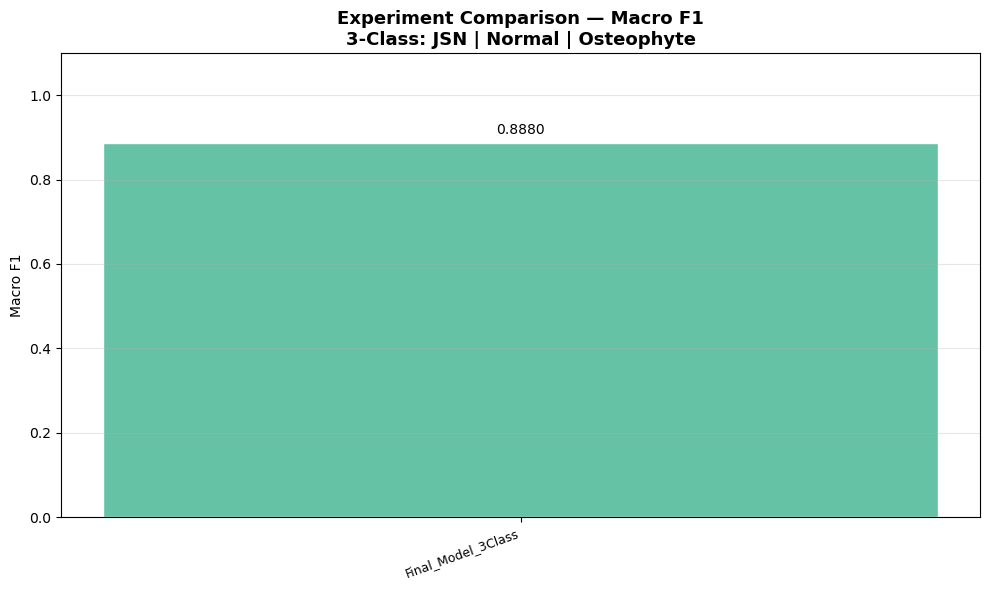

  Saved: results_3class/final\comparison_macro_f1.png


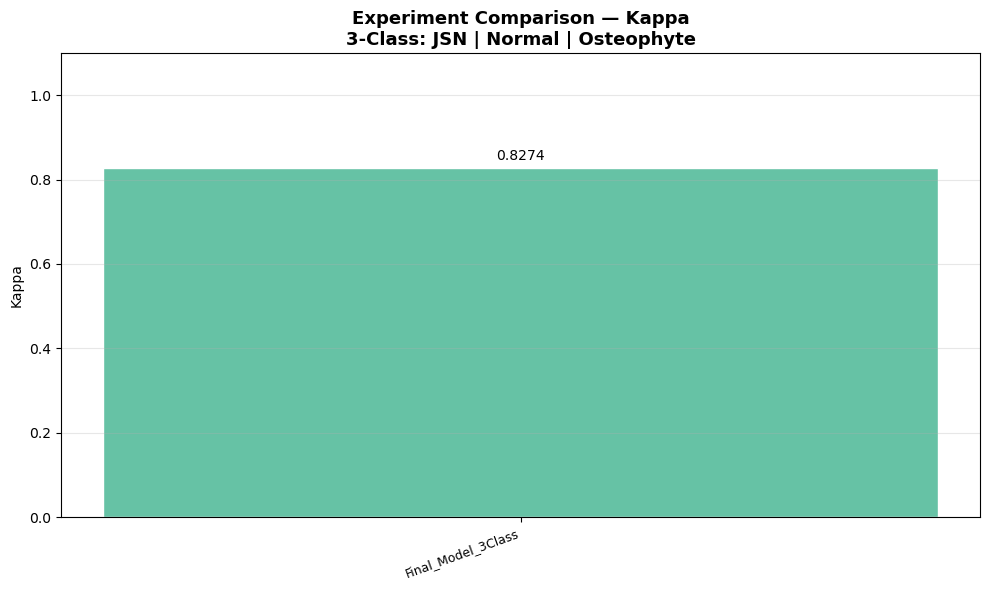

  Saved: results_3class/final\comparison_kappa.png


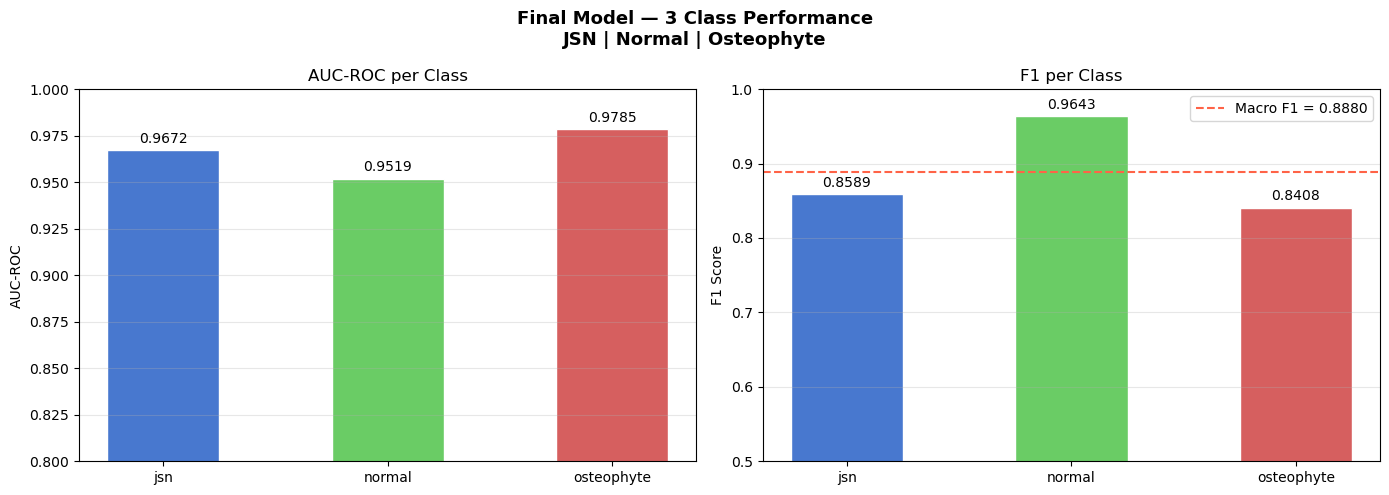


═════════════════════════════════════════════════════════════════
  WHAT STREAM 3-CLASS — PIPELINE COMPLETE
═════════════════════════════════════════════════════════════════
  Classes      : JSN | Normal | Osteophyte
  Sclerosis    : Removed (not relevant for KL0/1/2)
  Architecture : BaselineCNN 3 conv blocks (32→64→128)
  Augmentation : HFlip + Rotation±5° + ColorJitter
  LR           : 0.001
  Batch Size   : 32
  Dropout      : 0.3
  Weight Decay : 0.001

  Test Results:
  Macro F1     : 0.8880
  Cohen Kappa  : 0.8274
  Accuracy     : 0.9416

  JSN F1       : 0.8589  ← key early stage class
  Normal F1    : 0.9643
  Osteophyte F1: 0.8408

  Model saved  : results_3class/final/FINAL_MODEL_best.pth


In [8]:
# ══════════════════════════════════════════════════════════════
#  FINAL MODEL — 3 CLASS
#  Train with best HP from Exp5 on full 50 epochs
#  Evaluate on test set — first and only time
# ══════════════════════════════════════════════════════════════

os.makedirs("results_3class/final", exist_ok=True)

print("="*65)
print("  FINAL MODEL — 3 CLASS (JSN | Normal | Osteophyte)")
print("="*65)
print(f"  lr={best_params['lr']} | bs={best_params['bs']} | "
      f"dr={best_params['dr']} | wd={best_params['wd']}")

t_loader, v_loader, te_loader, _ = get_loaders(
    train_transform=transform_augmented,
    batch_size=best_params["bs"])
w    = compute_class_weights()
crit = nn.CrossEntropyLoss(weight=w)

final_model = BaselineCNN(
    num_classes=3,
    dropout=best_params["dr"]).to(DEVICE)
opt_final = torch.optim.Adam(
    final_model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["wd"])

history_final = run_training(
    final_model, t_loader, v_loader, crit, opt_final,
    save_path="results_3class/final/FINAL_MODEL_best.pth",
    exp_name="Final_Model_3Class",
    epochs=EPOCHS)

final_model.load_state_dict(
    torch.load("results_3class/final/FINAL_MODEL_best.pth",
               map_location=DEVICE))

plot_learning_curves(
    history_final, "Final_Model_3Class", "results_3class/final")

results_final = full_evaluate(
    final_model, te_loader,
    "Final_Model_3Class", "results_3class/final")
ALL_HISTORIES["Final_Model_3Class"] = history_final

# ── Full comparison table ──────────────────────────────────────
print("\n" + "═"*65)
print("  FULL COMPARISON — 3 CLASS EXPERIMENTS")
print("═"*65)
print(f"  {'Experiment':<32} {'Macro F1':>10} {'Kappa':>10}")
print(f"  {'-'*54}")

exp_order = [
    "Exp1_Baseline_3Class",
    "Exp2A_Dropout_3Class",
    "Exp2B_WeightDecay_3Class",
    "Exp2C_Augmentation_3Class",
    "Exp3A_Shallow_3Class",
    "Exp3B_Baseline_3Class",
    "Exp3C_Deep_3Class",
    "Final_Model_3Class"
]
for name in exp_order:
    if name in ALL_RESULTS:
        res    = ALL_RESULTS[name]
        marker = "→ " if name == "Final_Model_3Class" else "  "
        print(f"  {marker}{name:<30} "
              f"{res['macro_f1']:>10.4f} "
              f"{res['kappa']:>10.4f}")

plot_comparison(metric="macro_f1", save_dir="results_3class/final")
plot_comparison(metric="kappa",    save_dir="results_3class/final")

# ── AUC per class ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Final Model — 3 Class Performance\n"
    "JSN | Normal | Osteophyte",
    fontsize=13, fontweight="bold")

axes[0].bar(CLASS_NAMES, results_final["auc"],
            color=["#4878CF","#6ACC65","#D65F5F"],
            edgecolor="white", width=0.5)
axes[0].bar_label(axes[0].containers[0],
                   fmt="%.4f", padding=3)
axes[0].set_title("AUC-ROC per Class")
axes[0].set_ylabel("AUC-ROC")
axes[0].set_ylim(0.8, 1.0)
axes[0].grid(axis="y", alpha=0.3)

f1_per_class = [
    results_final["report"][cls]["f1-score"]
    for cls in CLASS_NAMES
]
axes[1].bar(CLASS_NAMES, f1_per_class,
            color=["#4878CF","#6ACC65","#D65F5F"],
            edgecolor="white", width=0.5)
axes[1].bar_label(axes[1].containers[0],
                   fmt="%.4f", padding=3)
axes[1].set_title("F1 per Class")
axes[1].set_ylabel("F1 Score")
axes[1].set_ylim(0.5, 1.0)
axes[1].axhline(y=results_final["macro_f1"],
                color="tomato", linestyle="--",
                linewidth=1.5,
                label=f"Macro F1 = "
                      f"{results_final['macro_f1']:.4f}")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "results_3class/final/final_per_class_performance.png",
    dpi=150, bbox_inches="tight")
plt.show()

# ── Final summary ──────────────────────────────────────────────
print("\n" + "═"*65)
print("  WHAT STREAM 3-CLASS — PIPELINE COMPLETE")
print("═"*65)
print(f"  Classes      : JSN | Normal | Osteophyte")
print(f"  Sclerosis    : Removed (not relevant for KL0/1/2)")
print(f"  Architecture : BaselineCNN 3 conv blocks (32→64→128)")
print(f"  Augmentation : HFlip + Rotation±5° + ColorJitter")
print(f"  LR           : {best_params['lr']}")
print(f"  Batch Size   : {best_params['bs']}")
print(f"  Dropout      : {best_params['dr']}")
print(f"  Weight Decay : {best_params['wd']}")
print(f"\n  Test Results:")
print(f"  Macro F1     : {results_final['macro_f1']:.4f}")
print(f"  Cohen Kappa  : {results_final['kappa']:.4f}")
print(f"  Accuracy     : "
      f"{results_final['report']['accuracy']:.4f}")
print(f"\n  JSN F1       : "
      f"{results_final['report']['jsn']['f1-score']:.4f}"
      f"  ← key early stage class")
print(f"  Normal F1    : "
      f"{results_final['report']['normal']['f1-score']:.4f}")
print(f"  Osteophyte F1: "
      f"{results_final['report']['osteophyte']['f1-score']:.4f}")
print(f"\n  Model saved  : "
      f"results_3class/final/FINAL_MODEL_best.pth")